# 📘 Tutorial 1: Higher-Dimensional Custom BO for Experimental Design Spaces

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Part 4**, we built standard Bayesian Optimisation workflows in BoTorch and studied how practical modelling choices affect their behaviour.

We saw that, once an initial dataset is available, we can repeatedly:

- fit a Gaussian Process surrogate,
- construct an acquisition function from that surrogate,
- optimise the acquisition function to choose the next point,
- evaluate the objective there,
- update the dataset,
- and continue the BO process over multiple iterations.

That established standard single-loop BO as a working optimisation workflow.

In this tutorial, we take the next step:

> **what changes when the optimisation problem is no longer low-dimensional, but instead lives in a genuinely higher-dimensional design space?**

That is the focus of this notebook.

This is an important shift.

In the earlier tutorials, BO was mostly studied in settings where the objective and the optimisation trajectory could still be visualised directly.
That was extremely useful for building intuition.

But in realistic research problems, the input space is often much richer.

A design vector may include many controllable variables at once, such as:

- synthesis temperature,
- precursor ratio,
- annealing time,
- pH,
- solvent composition,
- catalyst loading,
- reaction time,
- irradiation intensity,
- or other experimental conditions.

Once several such variables are allowed to vary simultaneously, the optimisation problem becomes genuinely high-dimensional.

At that point, the BO workflow itself remains the same in structure, but the way we **define**, **analyse**, and **interpret** the optimisation process has to change.

A higher-dimensional BO problem is not just:

- the same surrogate,
- plus the same acquisition function,
- plus more coordinates.

It also introduces new practical difficulties:

- the search space grows rapidly with dimension,
- the objective can no longer be visualised directly,
- the same evaluation budget becomes much less informative,
- and the acquisition optimisation itself becomes harder.

So this tutorial is not mainly about introducing a new BO algorithm.

It is about learning how to build and diagnose a BO workflow when the problem is no longer small enough to inspect geometrically.

To make this concrete, the notebook uses a **dimension-customisable benchmark objective** together with a reusable BO loop.

That lets us focus on several core questions:

- how to define a BO problem whose dimensionality can be changed by the user,
- how to initialise the search in a scalable way,
- how to analyse BO progress when direct surface plots are no longer available,
- and how budget and dimensionality affect what BO can realistically achieve.

This is also where the notebook begins to connect more directly to real experimental optimisation.

In realistic research settings, the main challenge is often not how to run a BO loop in principle, but how to use it when:

- the number of controllable variables is already moderate to large,
- each evaluation is expensive,
- and the total budget is limited.

That is exactly the setting this tutorial is designed to approach.

---

**This tutorial is designed to shift perspective**
- from *“I can run BO in a small, directly visualisable setting”*
- to *“I can build and interpret a BO workflow in a genuinely higher-dimensional design space.”*

---

**The emphasis is on developing intuition for**
- why high-dimensional BO is qualitatively harder than low-dimensional BO,
- how to define dimension-customisable benchmark problems,
- why Sobol initial designs are useful in higher-dimensional settings,
- how to analyse BO progress without relying on full objective visualisation,
- and why evaluation budget becomes especially important as dimension grows.

---

**Key ideas explored include**
- building a **dimension-customisable** BO setup,
- using a **Sobol initial design** in higher dimensions,
- constructing a reusable **high-dimensional BO loop**,
- interpreting BO through scalable diagnostics rather than full geometry,
- comparing BO behaviour across different dimensionalities,
- and studying how optimisation quality depends on the available evaluation budget.

---

This tutorial serves as the bridge from:

- **practical standard BO workflows** in Part 4,
- to **more realistic experimental BO settings** in Part 5.

In other words:

- **Part 4** showed how to build and analyse standard BO in BoTorch,
- and **Part 5 Tutorial 1** now asks what happens when BO is pushed into a more realistic multidimensional design space where visual intuition becomes limited and budget becomes a central constraint.

---

**Recommended prerequisites**
- Completion of **Part 4**
- Familiarity with Gaussian Process surrogates and acquisition functions in BoTorch
- Familiarity with the standard sequential BO loop
- Comfort with interpreting BO through best-value curves and diagnostic plots rather than only geometric visualisation

---

**Author**: Angze Li

**Last updated**: 2026-04-09

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.posteriors import GPyTorchPosterior
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.acquisition.analytic import (
    UpperConfidenceBound,
    LogExpectedImprovement,
    ProbabilityOfImprovement,
)

torch.set_default_dtype(torch.double)
torch.manual_seed(0)

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

## 1. Defining the high-dimensional BO problem setup

We begin by defining a small set of **user-configurable settings** that control the overall optimisation problem.

This is an important design choice for this tutorial.

In the earlier parts of the repository, the dimensionality of the objective was usually fixed by the example itself.
Here, by contrast, the goal is to build a BO workflow that can be adapted to **arbitrary input dimension**.

So this cell defines the core quantities that determine:

- how many variables are being optimised,
- how many initial observations are collected,
- how many BO iterations will be run,
- and what search region the optimiser is allowed to explore.

---

### What the code does

The first three lines define the main optimisation settings:

```python
dim = 5
n_init = 2 * dim
n_steps = 20
```

This means:

- the optimisation problem has **5 input variables**
- the BO loop begins with **10 initial observations**
- and then performs **20 sequential BO updates**

So the total number of objective evaluations in this worked example will be:

```python
n_init + n_steps = 10 + 20 = 30
```

That is intentionally a modest budget.
The goal of the notebook is not to assume unlimited evaluations, but to study how BO behaves when the number of runs is restricted.

---

### What `seed = 7` means

The line

```python
seed = 7
```

sets the random seed used by PyTorch through:

```python
torch.manual_seed(seed)
```

This controls the random number generator used in parts of the workflow such as:

- Sobol initial-design generation,
- randomised numerical procedures,
- and any other stochastic parts of the BO setup

The practical purpose is **reproducibility**.

That means if the notebook is run again with the same seed, the same code should produce the same random initial design and therefore the same BO trajectory, up to ordinary numerical consistency.

So the seed is not a modelling parameter in the optimisation problem itself.
It is a way of fixing the random state so that results can be reproduced and compared more reliably.

Using a specific seed such as `7` does not have special mathematical meaning.
It is simply a chosen integer used to initialise the pseudo-random sequence.

---

### What the bounds mean

The next lines define the lower and upper search limits:

```python
lower_bound = -2.0
upper_bound = 2.0
```

and then build the BoTorch bounds tensor:

```python
bounds = torch.tensor(
    [[lower_bound] * dim, [upper_bound] * dim],
    dtype=torch.double,
)
```

Since `dim = 5`, this means every variable is constrained to lie within:

```python
x_i \in [-2, 2]
```

for:

```python
i = 1, 2, 3, 4, 5
```

So the BO algorithm is allowed to search only inside the 5-dimensional box:

```python
[-2, 2]^5
```

This is what the `bounds` tensor is representing.

In BoTorch, bounds are conventionally stored in shape:

```python
(2, d)
```

where:

- the first row contains the lower bounds for all variables
- the second row contains the upper bounds for all variables

So here the printed shape:

```python
(2, 5)
```

confirms that the search region has been defined correctly for a 5-dimensional problem.

---

### Why the bounds matter

The bounds are not just a technical requirement for `optimize_acqf`.

They define the **feasible design space**.

That means they encode the region in which the optimiser is allowed to propose experiments or evaluations.

In real optimisation problems, these bounds would correspond to practical limits such as:

- allowable temperature ranges,
- concentration limits,
- pressure limits,
- reaction-time windows,
- or any other controllable experimental variables

So the bounds are the mechanism by which a high-dimensional BO problem is translated into a concrete search region.

---

### Why `n_init = 2 * dim` is used

The line

```python
n_init = 2 * dim
```

makes the initial design size scale automatically with the dimensionality.

This is a simple and useful default.

As the number of variables increases, the initial surrogate needs at least some increase in initial coverage of the search space.
Using `2 * dim` is not a universal rule, but it is a reasonable and easy-to-explain starting choice for a tutorial.

So this is part of what makes the notebook **dimension-customisable**:

- if `dim` changes,
- then the initial design size changes with it automatically.

---

### What `variable_names` is doing

The line

```python
variable_names = [f"x{i+1}" for i in range(dim)]
```

creates names for the input coordinates:

```python
['x1', 'x2', 'x3', 'x4', 'x5']
```

These labels are useful later when plotting coordinate traces or reporting candidate points.

In a real application, these could be replaced with meaningful names such as:

- temperature
- pH
- precursor_ratio
- reaction_time
- catalyst_loading

But for a tutorial, generic coordinate names are a clean default.

---

### Why this cell matters for the rest of the notebook

This cell establishes the overall optimisation problem in a way that is:

- simple,
- customisable,
- and scalable with dimension.

The important shift from earlier tutorials is that the notebook is no longer tied to one fixed low-dimensional example.
Instead, the dimensionality is a parameter of the workflow itself.

That is a key idea for this part of the series.

---

### Key takeaway

This cell defines the main high-dimensional BO setup:

- `dim = 5` specifies a 5-dimensional optimisation problem
- `n_init = 2 * dim` sets the initial design size
- `n_steps = 20` sets the BO budget after initialisation
- `seed = 7` makes the run reproducible
- and `bounds` defines the feasible search region `[-2, 2]^5`

Together, these quantities determine the scale, reproducibility, and allowable search space of the BO problem that the rest of the notebook will study.

In [2]:
dim = 5
n_init = 2 * dim
n_steps = 20
seed = 7

torch.manual_seed(seed)

lower_bound = -2.0
upper_bound = 2.0

bounds = torch.tensor(
    [[lower_bound] * dim, [upper_bound] * dim],
    dtype=torch.double,
)

variable_names = [f"x{i+1}" for i in range(dim)]

print("Input dimension:", dim)
print("Initial design size:", n_init)
print("BO steps:", n_steps)
print("Bounds shape:", tuple(bounds.shape))
print("Variable names:", variable_names)

Input dimension: 5
Initial design size: 10
BO steps: 20
Bounds shape: (2, 5)
Variable names: ['x1', 'x2', 'x3', 'x4', 'x5']


## 2. Defining a dimension-customisable Rosenbrock objective

To study high-dimensional Bayesian Optimisation in a controlled way, we need an objective function that is:

- defined for arbitrary input dimension,
- mathematically clear,
- nontrivial to optimise,
- and still structured enough that BO behaviour remains interpretable.

For this tutorial, we use a **shifted Rosenbrock function**.

This is a standard benchmark in optimisation, and it is often used because it is much more challenging than a simple quadratic bowl while still remaining smooth and well defined.

---

### What the code does

The function

```python
def objective_rosenbrock(X, center=None):
```

takes an input tensor `X` whose last dimension represents the optimisation variables.

So if

```python
X.shape == (n, d)
```

then the function evaluates the Rosenbrock objective at `n` points in a `d`-dimensional design space.

The line

```python
X = X.to(dtype=torch.double)
```

ensures that the function uses double precision, which is helpful for numerical stability in GP modelling and BO workflows.

---

### Why a `center` is introduced

The standard Rosenbrock function is usually written with its global minimum at the vector of all ones.

In this tutorial, however, we use a **shifted version**.

If no center is provided, the code defines:

```python
center = torch.linspace(-1.5, 1.5, d, dtype=torch.double, device=X.device)
```

So the target optimum is no longer at a trivial symmetric point like:

- all zeros
- or all ones

Instead, the optimum is placed at a dimension-dependent location spread across the domain.

This is useful because it makes the benchmark feel less artificial and avoids giving the optimiser a specially convenient target structure.

---

### What the transformation `Z = X - center + 1.0` means

The line

```python
Z = X - center + 1.0
```

is the key shift.

The usual Rosenbrock function has its minimum at:

```python
Z = (1, 1, ..., 1)
```

So by defining

```python
Z = X - center + 1
```

we make the minimum occur when

```python
X = center
```

That means the global optimum of this shifted benchmark lies exactly at the chosen `center` vector.

So the shift is simply a way of moving the standard Rosenbrock valley to a more interesting location inside the allowed search region.

---

### The mathematical form of the Rosenbrock function

The code computes:

```python
y = torch.sum(
    100.0 * (Z[..., 1:] - Z[..., :-1] ** 2) ** 2
    + (1.0 - Z[..., :-1]) ** 2,
    dim=-1
)
```

Mathematically, this corresponds to

$$
f(\mathbf{z}) = \sum_{i=1}^{d-1} \left[ 100\left(z_{i+1} - z_i^2\right)^2 + (1 - z_i)^2 \right].
$$

This is the standard Rosenbrock objective.

It is made of two coupled terms:

1. a **quadratic penalty**
   that encourages  $z_i \approx 1$

2. a **curved coupling term**
   that encourages $z_{i+1} \approx z_i^2$

Together, these create a narrow curved valley leading to the global minimum.

The function is then returned in shape `(n, 1)` using:

```python
return y.unsqueeze(-1)
```

which matches the scalar-output format expected by BoTorch.

---

### Why Rosenbrock is used in this tutorial

Rosenbrock is a good choice here because it is a useful middle ground.

Compared with a simple quadratic objective, it is much more realistic in the sense that it is:

- non-convex,
- anisotropic,
- and geometrically difficult.

But compared with something highly multimodal like Ackley or Rastrigin, it is usually more manageable for a first high-dimensional BO tutorial.

So Rosenbrock is a good benchmark when the goal is to demonstrate:

- that higher-dimensional BO is harder than low-dimensional BO,
- but without making the example so rugged that the optimisation looks hopeless under a modest budget.

---

### The main mathematical difficulty of Rosenbrock

The difficulty of Rosenbrock is not primarily that it has many local minima.

Instead, its main challenge is **geometry**.

The function has a narrow, curved valley leading to the optimum.
That means a good optimiser must do more than simply move downhill locally.
It must also:

- identify the valley,
- stay inside it,
- and continue making coordinated progress along a curved path.

In higher dimensions, this becomes even harder because the coordinates are coupled through terms like

$$
z_{i+1} - z_i^2.
$$

So progress in one dimension is not independent of the others.

That is one reason Rosenbrock is a useful test for BO in custom-dimensional spaces.

---

### Advantages of using Rosenbrock here

Using Rosenbrock in this notebook has several advantages.

#### 1. It scales naturally with dimension
The function is defined for arbitrary $d$, so the same workflow can be used for:

- 2D,
- 4D,
- 5D,
- 8D,
- or higher.

That is exactly what we need for a custom-dimensional tutorial.

#### 2. It has a known optimum
Because the optimum is placed at `center`, we know the true best point and true best value in advance.

This lets us evaluate BO behaviour quantitatively through diagnostics such as:

- best observed value,
- simple regret,
- and distance to the known optimum.

#### 3. It is difficult, but not impossibly chaotic
Rosenbrock is much harder than a sphere function, but it is usually more pedagogically useful than a very rugged benchmark for a first high-dimensional BO example.

So it gives us a meaningful optimisation challenge without making the notebook purely about failure.

#### 4. It highlights geometric difficulty
This is important because many real optimisation problems are difficult not because they have a huge number of local minima, but because:

- good regions are narrow,
- variables are coupled,
- and progress requires coordinated movement across dimensions.

Rosenbrock reflects that kind of difficulty reasonably well.

---

### How Rosenbrock differs from practical optimisation problems

Even though Rosenbrock is useful, it is still a **benchmark function**, not a realistic scientific objective.

There are several important differences.

#### 1. It is noise-free
The Rosenbrock function is deterministic.
For a given input, it always returns the same value.

Real optimisation problems often involve:

- experimental noise,
- simulation noise,
- or measurement uncertainty.

So it does not capture the stochasticity of many practical BO settings.

#### 2. It is fully well-behaved mathematically
Rosenbrock is smooth and always evaluable.

Real experimental objectives may instead have:

- failed experiments,
- missing values,
- discontinuities,
- unstable regimes,
- or feasibility constraints.

So the benchmark is cleaner than real optimisation problems.

#### 3. It uses continuous variables only
This function assumes the input space is fully continuous.

Real design spaces often include:

- integer settings,
- categorical choices,
- and constrained variable combinations.

So it does not yet capture mixed-variable or constrained optimisation.

#### 4. Its structure is fixed and known to us
In a tutorial, we know that Rosenbrock has a single global optimum and a narrow valley.

In real black-box optimisation, the underlying geometry is rarely known in advance.

So the benchmark is valuable for controlled study, but not a substitute for actual domain-specific objectives.

---

### Why it is still a good tutorial choice

Despite these differences, Rosenbrock is still a strong choice for this notebook because it allows us to study the BO workflow under a controlled but genuinely nontrivial objective.

In particular, it helps us show that:

- higher-dimensional BO can already become difficult even in smooth settings,
- variable coupling matters,
- and the challenge of BO is not only about ruggedness, but also about geometry and sample efficiency.

That makes it a good bridge between toy examples and real-world multidimensional optimisation.

---

### Key takeaway

This cell defines a **shifted Rosenbrock objective** that can be used in arbitrary dimension.

Mathematically, the function is built from coupled quadratic penalties that create a narrow curved valley leading to the global optimum.

Rosenbrock is used here because it is:

- dimension-general,
- harder than a simple quadratic,
- easier to interpret than very rugged multimodal benchmarks,
- and well suited to illustrating the geometric difficulty of higher-dimensional BO.

At the same time, it still differs from real optimisation problems because it is smooth, deterministic, fully continuous, and always well behaved.
So it should be understood as a useful controlled benchmark rather than a realistic scientific objective.

In [3]:
def objective_rosenbrock(X, center=None):
    X = X.to(dtype=torch.double)
    d = X.shape[-1]

    if center is None:
        center = torch.linspace(-1.5, 1.5, d, dtype=torch.double, device=X.device)

    if center.ndim == 1:
        center = center.unsqueeze(0)

    Z = X - center + 1.0
    y = torch.sum(100.0 * (Z[..., 1:] - Z[..., :-1] ** 2) ** 2 + (1.0 - Z[..., :-1]) ** 2, dim=-1)

    return y.unsqueeze(-1)

## 3. Inspecting the known optimum and a random point

Now that the shifted Rosenbrock objective has been defined, it is useful to inspect two concrete points:

- the **known optimum**
- and a **random point** sampled from the search domain

This helps make the high-dimensional objective more tangible before the BO loop begins.

Since the full objective surface cannot be visualised directly in five dimensions, small diagnostic checks like this become especially helpful.

---

### What the code does

The first two lines define the location of the known optimum:

```python
x_opt = torch.linspace(-1.5, 1.5, dim, dtype=torch.double).unsqueeze(0)
y_opt = objective_rosenbrock(x_opt)
```

Because the shifted Rosenbrock objective was constructed so that its minimum occurs at the chosen `center`, this point `x_opt` is the true global optimum of the benchmark.

The value `y_opt` is then the true minimum objective value.

For Rosenbrock, that minimum is:

```python
0.0
```

which is exactly what the printed output confirms.

---

### Why `x_opt` is defined this way

The vector

```python
torch.linspace(-1.5, 1.5, dim)
```

creates a dimension-dependent coordinate sequence spread between `-1.5` and `1.5`.

So when `dim = 5`, the optimum coordinates become:

```python
[-1.5, -0.75, 0.0, 0.75, 1.5]
```

This is not a random choice.

It is the same default `center` used inside `objective_rosenbrock(...)`, so this vector is exactly the point at which the shifted objective reaches its minimum.

The `.unsqueeze(0)` simply changes the shape from:

```python
(5,)
```

to:

```python
(1, 5)
```

so that the point is represented in the standard batch format expected by the objective function.

---

### Why a random point is also evaluated

The next lines construct a random point inside the search bounds:

```python
x_random = lower_bound + (upper_bound - lower_bound) * torch.rand(1, dim, dtype=torch.double)
y_random = objective_rosenbrock(x_random)
```

This provides a useful contrast.

The known optimum gives the best possible objective value, while the random point gives a typical non-optimal value from elsewhere in the domain.

That comparison helps us build intuition for the scale of the optimisation problem.

In the output shown here:

- the optimum value is `0.0`
- while the random point gives a much larger value

This is exactly what we expect, since Rosenbrock is constructed so that the minimum is sharply concentrated around the optimum valley.

So this small diagnostic already shows that:

- most random points in the domain are far from optimal
- and BO will need to discover a very specific region to achieve strong performance

---

### Why the printed shapes matter

The output confirms that both points have shape:

```python
(1, 5)
```

This is important because it matches the expected input format for BoTorch-style objective evaluation:

- one point
- in a 5-dimensional design space

So this cell also quietly verifies that the benchmark is being used in the correct tensor shape.

---

### Why the known optimum is useful later

Having access to the true optimum is valuable in a synthetic tutorial setting.

It allows us to later compute diagnostics such as:

- best observed value over BO iterations
- distance between the best found point and the true optimum

These diagnostics would not usually be available in a real black-box optimisation problem, but they are very useful here because they let us evaluate the BO loop against a known reference.

So this cell establishes that reference explicitly before the optimisation begins.

---

### Why this kind of inspection matters in high-dimensional BO

In lower dimensions, we could often understand the objective by plotting it directly.

In higher dimensions, that is no longer possible.

So instead of relying on full visualisation, we often use diagnostic checks like:

- known optimum value
- random-point evaluations
- projections of sampled points
- and regret curves

This cell is the first example of that shift in analysis style.

It makes the high-dimensional objective concrete without pretending that the full 5D landscape can be seen directly.

---

### Key takeaway

This cell evaluates the shifted Rosenbrock objective at:

- the known global optimum `x_opt`
- and a random point `x_random` inside the search region

The output confirms that:

- the optimum has value `0.0`
- random points can have much larger values
- and the benchmark is being evaluated in the correct `(1, d)` tensor format

This gives us a concrete reference point before the Bayesian Optimisation loop begins.

In [4]:
x_opt = torch.linspace(-1.5, 1.5, dim, dtype=torch.double).unsqueeze(0)
y_opt = objective_rosenbrock(x_opt)

x_random = lower_bound + (upper_bound - lower_bound) * torch.rand(1, dim, dtype=torch.double)
y_random = objective_rosenbrock(x_random)

print("Known optimum location shape:", tuple(x_opt.shape))
print("Known optimum value:", y_opt.item())
print("Random point shape:", tuple(x_random.shape))
print("Objective at a random point:", y_random.item())

print("\nKnown optimum coordinates:")
for name, value in zip(variable_names, x_opt.squeeze(0).tolist()):
    print(f"{name}: {value:.4f}")

Known optimum location shape: (1, 5)
Known optimum value: 0.0
Random point shape: (1, 5)
Objective at a random point: 3254.2210058334745

Known optimum coordinates:
x1: -1.5000
x2: -0.7500
x3: 0.0000
x4: 0.7500
x5: 1.5000


## 4. Generating the initial high-dimensional dataset with a Sobol design

Before the sequential BO loop can begin, we need an initial set of observed input–output pairs.

In low-dimensional toy examples, it is sometimes easy to hand-pick a few starting points.
But in a genuinely custom-dimensional setting, that approach no longer scales well.

So in this tutorial, the initial design is generated automatically using a **Sobol sequence**.

This is a very common and very useful practical choice for high-dimensional BO.

---

### What the code does

The main line is:

```python
train_X = draw_sobol_samples(bounds=bounds, n=1, q=n_init).squeeze(0)
```

This draws `n_init` initial points inside the search bounds using a Sobol design.

Since:

- `dim = 5`
- `n_init = 10`

the resulting tensor `train_X` has shape:

```python
(10, 5)
```

meaning:

- 10 initial evaluation points
- in a 5-dimensional design space

The next line evaluates the Rosenbrock objective at those points:

```python
train_Y = objective_rosenbrock(train_X)
```

So `train_Y` has shape:

```python
(10, 1)
```

which matches the standard BoTorch convention for scalar outputs.

Finally, the code prints:

- the shape of `train_X`
- the shape of `train_Y`
- and the best observed objective value among the initial points

This gives a quick summary of the initial dataset before BO begins.

---

### What a Sobol design is

A Sobol design is a type of **low-discrepancy sequence**, sometimes described as a **quasi-random design**.

It is not a rigid grid, but it is also not the same as naive independent random sampling.

The key idea is that Sobol points are generated so that they tend to **fill the search space more evenly** than ordinary random points.

So instead of producing initial points that may accidentally cluster together, a Sobol sequence tries to spread the points out more uniformly across the domain.

This is especially helpful when the dimensionality increases.

---

### Why not just use random initial points?

A natural alternative would be to generate the initial design with simple uniform random sampling.

That would certainly work, but it often produces poorer coverage.

In particular, purely random initial points can:

- cluster together by chance,
- leave large regions of the domain poorly covered,
- and provide a less informative starting surrogate for the same initial evaluation budget

That is not ideal in BO, because the quality of the initial dataset strongly influences the early GP fit and therefore the early acquisition decisions.

So while random initialisation is simple, it is usually not the best default if we care about getting a reasonably informative initial design.

---

### Why Sobol is a good choice here

Using a Sobol design has several important advantages.

#### 1. It scales naturally with dimension
This is one of the biggest reasons it is useful here.

The whole point of this tutorial is that the dimensionality can be customised by the user.

A Sobol sequence works cleanly whether the design space is:

- 2D,
- 5D,
- 10D,
- or higher.

So it is a much better default than manually chosen points.

---

#### 2. It gives better space-filling coverage than naive random sampling
For a fixed initial budget, Sobol points usually cover the domain more evenly than ordinary random points.

That means the GP begins with a more informative view of the design space.

In practice, this often helps BO by:

- reducing accidental clustering,
- improving early surrogate quality,
- and giving the acquisition function a better starting point

So Sobol improves the initial **sample efficiency** of the workflow.

---

#### 3. It is especially useful in higher dimensions
As dimension increases, poor initial coverage becomes a bigger problem.

In one or two dimensions, a weak initial design may still give the model some rough sense of the domain.
In five or more dimensions, that becomes much less true.

So using a space-filling initial design is particularly important once BO moves beyond low-dimensional toy examples.

This is one reason Sobol is such a common default in BoTorch workflows.

---

#### 4. It is simple to use in BoTorch
Another practical advantage is that BoTorch already provides a clean helper for this:

```python
draw_sobol_samples(...)
```

So the design is not only statistically useful, but also easy to generate programmatically.

That makes it an excellent tutorial choice.

---

### Why the bounds are passed into `draw_sobol_samples`

The Sobol design is generated inside the search region specified by `bounds`.

That means every initial point already respects the feasible domain:

```python
[-2, 2]^5
```

So the initial dataset is immediately compatible with the later BO loop, and no extra rescaling or filtering is needed afterward.

This is another reason the Sobol approach is so convenient.

---

### What the printed best initial value tells us

The line

```python
print("Initial best observed value:", torch.min(train_Y).item())
```

gives the best objective value found in the initial design before any BO updates have occurred.

This is useful because it gives us a starting baseline.

Later in the notebook, when we plot the best observed value over BO iterations, we will be able to see how much BO improves relative to this initial starting point.

So this value is the performance level that the BO loop inherits from the initial Sobol design.

---

### Why this matters in a real-world workflow

In real experimental optimisation, the initial design is often the first expensive batch of experiments.

That means a poor initial design can waste both:

- time,
- and budget

before BO even begins to adapt sequentially.

Using a structured, space-filling design like Sobol is therefore not just a mathematical nicety.
It is a practical way to make the initial evaluations more informative for the same experimental cost.

So this design choice is very realistic and very defensible in an applied BO workflow.

---

### Key takeaway

This cell generates the initial dataset for high-dimensional BO using a **Sobol design**.

Sobol is used because it provides a space-filling, dimension-scalable, and practical alternative to naive random initialisation.

Compared with ordinary random sampling, it usually gives:

- better early coverage of the search space,
- a more informative initial GP surrogate,
- and a better starting point for the BO loop.

That makes it a strong default choice for dimension-customisable Bayesian Optimisation workflows.

In [5]:
from botorch.utils.sampling import draw_sobol_samples

train_X = draw_sobol_samples(bounds=bounds, n=1, q=n_init).squeeze(0)
train_Y = objective_rosenbrock(train_X)

print("\ntrain_X shape:", tuple(train_X.shape))
print("train_Y shape:", tuple(train_Y.shape))
print("Initial best observed value:", torch.min(train_Y).item())


train_X shape: (10, 5)
train_Y shape: (10, 1)
Initial best observed value: 2207.5583802629226


## 5. Defining a reusable high-dimensional BO loop

With the objective and initial dataset now in place, we can build the main computational engine of the notebook: a **reusable Bayesian Optimisation loop** that works for arbitrary input dimension.

This is the key structural shift of the tutorial.

In earlier low-dimensional examples, it was feasible to build BO workflows closely tied to a specific plotting setup or a fixed objective dimension.
Here, by contrast, the BO loop is written so that it can be reused whenever:

- the input dimension changes,
- the search bounds change,
- the objective changes,
- or the BO budget changes.

So the purpose of this function is not just to run one example.
It is to provide a general high-dimensional BO workflow.

---

### What the function does

The function

```python
def run_high_dim_bo_loop(...):
```

takes:

- an initial observed dataset,
- a black-box objective function,
- a set of search bounds,
- and a BO budget,

and then runs a standard sequential BO loop for `n_steps` iterations.

At a high level, each BO iteration does the following:

1. converts the minimisation problem into a maximisation-compatible form
2. fits a Gaussian Process surrogate
3. constructs a Log Expected Improvement acquisition function
4. optimises that acquisition function to choose the next candidate
5. evaluates the objective at that candidate
6. appends the new observation to the dataset
7. stores the relevant BO state in `history`

So this function packages the full repeated BO workflow into one reusable unit.

---

### Why `train_X` and `train_Y` are cloned first

The lines

```python
train_X = train_X_init.clone()
train_Y = train_Y_init.clone()
```

make local copies of the input dataset before the BO loop begins.

This is good practice because it avoids modifying the original tensors passed into the function.

So the BO loop can safely evolve its own internal dataset over time while preserving the original initial design outside the function.

---

### How the GP surrogate is built

The function then fits a GP using:

```python
gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y_bo,
    input_transform=Normalize(d=train_X.shape[-1]),
    outcome_transform=Standardize(m=1),
)
```

This means:

- the GP input dimension is inferred automatically from the data
- the inputs are normalised internally
- and the scalar outputs are standardised internally

This is a very sensible default for high-dimensional BO.

It keeps the GP fit numerically more stable and avoids hard-coding the dimensionality into the loop.

So the function remains customisable with respect to `d`.

---

### Why `Normalize(d=train_X.shape[-1])` is used

This line is especially important:

```python
Normalize(d=train_X.shape[-1])
```

Rather than writing something like `Normalize(d=5)`, the code uses:

```python
train_X.shape[-1]
```

to infer the dimensionality directly from the current input data.

That means the same BO loop can work without modification for:

- 2D,
- 5D,
- 8D,
- 10D,
- or higher-dimensional inputs,

as long as the initial data and bounds are provided consistently.

This is exactly the kind of design needed in a truly custom-dimensional BO workflow.

---

### What `num_restarts` and `raw_samples` are doing here

The next candidate is chosen with:

```python
candidate, acq_value = optimize_acqf(
    acq_function=log_ei,
    bounds=bounds,
    q=1,
    num_restarts=num_restarts,
    raw_samples=raw_samples,
)
```

This is where the acquisition function is numerically optimised.

Here:

- `raw_samples` controls how many random trial points are generated first to explore the acquisition landscape
- `num_restarts` controls how many local optimisation runs are then launched from promising starting points
- `q=1` means we are selecting **one candidate at a time**

These settings matter because acquisition optimisation is itself a nontrivial numerical problem, especially once the dimensionality increases.

So this BO loop is not just fitting a surrogate.
It is also solving an inner optimisation problem at every iteration.

---

### Why lengthscale and noise are stored

After fitting the GP, the code extracts:

```python
lengthscale = gp.covar_module.lengthscale.detach().cpu().reshape(-1).numpy()
noise = gp.likelihood.noise.detach().cpu().item()
```

These are useful model diagnostics.

The learned **lengthscales** tell us how the GP is interpreting variation across each input dimension.

The learned **noise** tells us how much observational uncertainty the GP thinks it needs to explain the data.

In high-dimensional BO, these quantities are often more informative than a direct surface plot, because they show how the surrogate itself is adapting internally.

That is why they are stored in `history`.

---

### Why the current best point is stored explicitly

The code also computes:

```python
best_idx = torch.argmin(train_Y)
best_x = train_X[best_idx].clone()
best_y = train_Y[best_idx].clone()
```

This stores the best point found **so far** at each BO step.

That is useful because later analysis often focuses not just on all sampled points, but specifically on:

- how the best value improves,
- and how the best found coordinates evolve over time

So keeping `best_x` and `best_y` in the stored history makes downstream analysis much easier.

---

### How the dataset is updated

At the end of each iteration, unless the loop has finished, the code does:

```python
x_new = candidate
y_new = objective_fn(x_new)

train_X = torch.cat([train_X, x_new], dim=0)
train_Y = torch.cat([train_Y, y_new], dim=0)
```

This is the heart of sequential BO.

The new candidate suggested by the acquisition function is evaluated on the true objective, and the resulting observation is appended to the dataset.

Then the next iteration fits a new surrogate to this updated dataset.

So the loop is genuinely sequential: every new decision depends on all the data collected so far.

---

### Why this function is important for the rest of the notebook

This function is the main engine that makes the tutorial scalable.

It is written so that:

- the input dimension is not hard-coded,
- the objective function is user-replaceable,
- the search bounds are user-defined,
- and the BO budget is configurable.

That means it can be used both for:

- the synthetic Rosenbrock example in the notebook,
- and the real-world-ready BO template at the end.

So this function is not just part of the example.
It is the central reusable BO component that the rest of the tutorial builds on.

---

### How this differs from low-dimensional BO workflows

In a low-dimensional tutorial, a BO loop is often built mainly to support visualisation:

- posterior surfaces,
- acquisition curves,
- next-point overlays,
- and geometric interpretations of the search space

In this notebook, that is no longer the main priority.

Because the input dimension is arbitrary, the loop is instead designed to support analysis through:

- stored BO history,
- best-value curves,
- coordinate traces,
- sampled-point projections,
- and model-hyperparameter trajectories

So the emphasis shifts from direct geometric visualisation to scalable BO diagnostics.

---

### Key takeaway

This cell defines a reusable **high-dimensional Bayesian Optimisation loop**.

At each iteration, the function:

1. fits a GP surrogate to the current data,
2. constructs a Log Expected Improvement acquisition function,
3. optimises it to choose the next candidate,
4. evaluates the objective there,
5. updates the dataset,
6. and stores the BO state for later analysis.

The loop is written so that the dimensionality is inferred directly from the data, which makes it suitable for genuinely custom-dimensional BO problems rather than fixed toy examples.

In [6]:
def run_high_dim_bo_loop(
    train_X_init,
    train_Y_init,
    objective_fn,
    bounds,
    n_steps=30,
    num_restarts=20,
    raw_samples=256
):
    train_X = train_X_init.clone()
    train_Y = train_Y_init.clone()

    history = []

    for step in range(n_steps + 1):
        train_Y_bo = -train_Y
        y_best_bo = train_Y_bo.max().item()

        gp = SingleTaskGP(
            train_X=train_X,
            train_Y=train_Y_bo,
            input_transform=Normalize(d=train_X.shape[-1]),
            outcome_transform=Standardize(m=1),
        )
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        fit_gpytorch_mll(mll)
        gp.eval()

        log_ei = LogExpectedImprovement(model=gp, best_f=y_best_bo)
        candidate, acq_value = optimize_acqf(
            acq_function=log_ei,
            bounds=bounds,
            q=1,
            num_restarts=num_restarts,
            raw_samples=raw_samples,
        )

        lengthscale = gp.covar_module.lengthscale.detach().cpu().reshape(-1).numpy()
        noise = gp.likelihood.noise.detach().cpu().item()

        best_idx = torch.argmin(train_Y)
        best_x = train_X[best_idx].clone()
        best_y = train_Y[best_idx].clone()

        history.append({
            "step": step,
            "train_X": train_X.clone(),
            "train_Y": train_Y.clone(),
            "candidate": candidate.clone(),
            "acq_value": acq_value.clone(),
            "lengthscale": lengthscale.copy(),
            "noise": noise,
            "best_x": best_x.clone(),
            "best_y": best_y.clone(),
        })

        if step < n_steps:
            x_new = candidate
            y_new = objective_fn(x_new)

            train_X = torch.cat([train_X, x_new], dim=0)
            train_Y = torch.cat([train_Y, y_new], dim=0)

    return history

## 6. Running the high-dimensional BO loop

With the reusable BO loop now defined, we can run it on the current 5-dimensional Rosenbrock problem.

This is the point where the notebook shifts from **problem setup** to **actual sequential optimisation**.

The code below takes:

- the Sobol initial dataset,
- the shifted Rosenbrock objective,
- the 5-dimensional search bounds,
- and the BO budget,

and executes the full Bayesian Optimisation workflow for `n_steps` iterations.

---

### What the code does

The main call is:

```python
history = run_high_dim_bo_loop(
    train_X_init=train_X,
    train_Y_init=train_Y,
    objective_fn=objective_rosenbrock,
    bounds=bounds,
    n_steps=n_steps,
    num_restarts=20,
    raw_samples=256
)
```

This runs the reusable BO loop defined earlier using:

- the current initial observed dataset `train_X`, `train_Y`
- the Rosenbrock objective
- the current search region `bounds`
- and the chosen BO budget `n_steps`

The result is stored in `history`, which contains the full sequential BO record over all iterations.

That means `history` stores, at each BO step:

- the observed dataset so far
- the candidate chosen by the acquisition function
- the learned GP lengthscales
- the learned GP noise
- and the best point found so far

So this object is the main source of all later diagnostics and plots.

---

### Why `num_restarts=20` is used

The argument

```python
num_restarts=20
```

controls how many separate local optimisation runs BoTorch performs when maximising the acquisition function.

This matters because the acquisition function is usually **non-convex**, especially in higher dimensions.

That means it can have:

- multiple local maxima
- flat regions
- irregular geometry
- and optimisation traps

If we used only a very small number of restarts, the acquisition optimiser might settle for a mediocre local maximum simply because it never searched enough starting points.

By using `num_restarts=20`, we make the acquisition optimisation substantially more thorough.

So the practical meaning is:

- BoTorch will try **20 different local starting points**
- and then keep the best acquisition maximiser it finds

This is especially important in a 5-dimensional BO problem, because the inner acquisition-optimisation problem is already much harder than in the earlier 1D and 2D tutorials.

So `num_restarts=20` is used here to improve the reliability of the acquisition step.

---

### Why `raw_samples=256` is used

The argument

```python
raw_samples=256
```

controls how many random trial points BoTorch draws before launching those local optimisation restarts.

These raw samples are used to identify promising starting points for the local optimisation phase.

So the logic is:

1. generate many random trial points across the domain
2. evaluate the acquisition function at those points
3. choose the most promising ones as initial conditions
4. run local optimisation from those initial conditions

In this sense:

- `raw_samples` controls the quality of the **candidate pool**
- `num_restarts` controls how many of those candidate starts are then refined

Using `raw_samples=256` means the acquisition optimiser gets a fairly broad initial scan of the 5D search space before deciding where to start local optimisation.

This is useful because, in higher dimensions, the acquisition landscape can be complicated enough that too few raw samples may miss important promising regions altogether.

So the practical role of `raw_samples=256` is to make the acquisition optimiser less myopic and less dependent on a very small random initial search.

---

### Why these settings are larger than in earlier tutorials

In the earlier BoTorch notebooks, smaller values such as:

- `num_restarts=10`
- `raw_samples=50`

were often sufficient because the optimisation problems were:

- lower dimensional
- easier to visualise
- and less difficult for the acquisition optimiser to search

Here, however, we are already in a genuinely higher-dimensional setting.

That means the **inner optimisation problem** for the acquisition function is also harder.

So these larger values are used for a practical reason:

> once the BO problem becomes higher-dimensional, the acquisition optimiser itself usually needs a more serious search effort.

In other words, this is not just “tuning for the sake of tuning.”
It reflects a real increase in optimisation difficulty.

---

### What the printed summary means

#### Number of stored BO states
This tells us how many BO snapshots were recorded in `history`.

Because the loop stores the initial state and then each updated state, the number of stored states is usually:

```python
n_steps + 1
```

#### Final number of observations
This tells us how many objective evaluations are available by the end of the BO run.

It includes:

- the initial Sobol design
- plus all points added during sequential BO

So this is the total evaluation budget actually used.

#### Final best observed value
This is the best objective value BO has found by the end of the run.

This is one of the most practically important outputs, because in a real black-box optimisation problem this is exactly the kind of quantity we care about.

#### Known optimum value
This is printed only because this tutorial uses a synthetic benchmark with a known optimum.

It is useful here as a reference point, but it should be interpreted as a benchmark convenience rather than something a real-world optimisation problem would normally provide.

---

### Why this cell matters in the notebook

This is the first point in the notebook where the full custom-dimensional BO workflow is actually executed.

Everything before this was setup:

- define the dimension
- define the benchmark
- inspect the optimum
- generate the initial design
- build the reusable BO loop

This cell is where those pieces are finally combined into one complete high-dimensional optimisation run.

So it is the computational transition from **definition** to **behaviour**.

---

### What to expect next

Once `history` has been created, we can analyse the BO run using diagnostics that still make sense in higher dimensions, such as:

- best observed value over iterations
- projections of sampled points onto coordinate pairs
- candidate-coordinate traces
- learned GP lengthscales
- and comparisons across different dimensionalities

That is the main analytical strategy for the rest of the notebook.

Because the full 5D objective cannot be directly visualised, the stored BO history becomes the main object through which we understand the optimisation process.

---

### Key takeaway

This cell runs the full high-dimensional Bayesian Optimisation loop on the current 5D Rosenbrock problem.

The settings

- `num_restarts=20`
- `raw_samples=256`

are used because acquisition optimisation becomes significantly harder in higher dimensions.

Here:

- `raw_samples=256` gives a broad random initial scan of the acquisition landscape
- `num_restarts=20` gives many local refinement attempts from promising starting points

Together, these make the acquisition step more reliable and better suited to a genuinely high-dimensional BO setting.

In [7]:
history = run_high_dim_bo_loop(
    train_X_init=train_X,
    train_Y_init=train_Y,
    objective_fn=objective_rosenbrock,
    bounds=bounds,
    n_steps=n_steps,
    num_restarts=20,
    raw_samples=256
)

print("Number of stored BO states:", len(history))
print("Final number of observations:", history[-1]["train_X"].shape[0])
print("Final best observed value:", torch.min(history[-1]["train_Y"]).item())
print("Known optimum value:", y_opt.item())

Number of stored BO states: 21
Final number of observations: 30
Final best observed value: 52.527477459743906
Known optimum value: 0.0


## 7. Tracking BO progress through the best observed value and the best-so-far coordinates

In a genuinely high-dimensional BO problem, it is often no longer very informative to visualise the optimisation process through simple 2D projections of all sampled points.

Instead, a more useful question is:

> **How is the best solution found so far evolving over the BO run?**

That is exactly what this figure is designed to show.

The two panels focus on:

- **how much the best objective value improves over time**
- and **how the coordinates of the current best point change as better solutions are discovered**

This is a much more informative way to understand BO progress in higher dimensions.

---

### What the code does

The first two lines extract, from each stored BO state:

- the best objective value found so far
- and the coordinates of the best point found so far

```python
best_vals = [float(h["best_y"]) for h in history]
best_xs = torch.stack([h["best_x"] for h in history], dim=0)
```

So:

- `best_vals[t]` is the best objective value available after BO step `t`
- `best_xs[t]` is the corresponding best point in the design space at that step

The figure then creates two side-by-side panels.

#### Left panel
The left panel plots the **best observed value over BO iterations**.

#### Right panel
The right panel plots the coordinates of the **best-so-far point** over BO iterations, one line per variable.

Together, these two views show both:

- **when** BO improves
- and **how** the best solution itself changes when improvement happens

---

### How to read the left panel

The left panel is the standard cumulative BO performance plot.

Each point answers the question:

> *What is the lowest objective value found anywhere in the dataset so far?*

Because this is a minimisation problem:

- lower is better
- the curve can only stay flat or go down
- and each drop corresponds to a genuine improvement in the best found solution

So the left panel tells us **when** the BO loop finds a better region of the search space.

Flat segments mean that recent BO evaluations did not beat the current best point.
Sharp drops mean that BO found a new and substantially better solution.

---

### How to read the right panel

The right panel shows something different but complementary.

Instead of plotting all sampled points, it tracks the coordinates of the **current best point** over BO iterations.

Each coloured line corresponds to one variable:

- `x1`
- `x2`
- `x3`
- `x4`
- `x5`

At each BO step, the plotted coordinate values correspond to the point that currently has the lowest observed objective value.

So this panel should be read as:

> **When the best solution changes, which coordinates changed with it?**

This is why the lines look piecewise constant.

---

### Why the right-panel lines look like step functions

The right panel often shows long flat plateaus followed by sudden jumps.

This is expected.

The reason is that the panel does **not** track the newly proposed BO candidate at every iteration.
Instead, it tracks the coordinates of the **best-so-far point**.

That means:

- if a new BO evaluation does **not** improve on the current best point, then the best-so-far solution stays unchanged
- and therefore all coordinate traces remain flat

Only when BO discovers a point with a better objective value do the plotted coordinates update to that new best point.

So the step-like behaviour is exactly what we should expect.

The right panel is therefore not showing smooth coordinate motion through the search space.
It is showing a sequence of **best-solution replacements**.

---

### How the two panels relate to each other

A very useful way to interpret the figure is to read the two panels together.

- whenever the **left panel drops**, the BO loop has found a new best point
- and at exactly those same BO steps, the **right panel changes level**

So the right-panel jumps are the coordinate-level explanation of the left-panel performance improvements.

This makes the figure especially useful, because it tells us not only that BO improved, but also how the identity of the best solution changed when that improvement occurred.

---

### Rationalising the behaviour of the right panel in the attached result

In the attached figure, the right panel shows several clear jumps separated by flat regions.

This means the BO loop is behaving in a very natural way:

1. it keeps a particular point as the best solution for several iterations
2. then, at certain BO steps, it discovers a better point
3. that new point becomes the new best-so-far solution
4. and its full coordinate vector replaces the old one in the trace

So the best-so-far trajectory is not a smooth path.
It is a sequence of **discrete upgrades**.

This is actually a very useful perspective in a realistic BO setting.

In real optimisation problems, we often care less about the full sequence of all candidates and more about the question:

> *What is the best condition we would choose if the optimisation stopped at this point?*

The right panel answers exactly that question across BO iterations.

---

### Why this is more useful than plotting all sampled points in 2D

In high dimensions, plotting all sampled points in pairwise projections often mixes together:

- initial Sobol points
- exploratory points
- exploitative points
- good points
- bad points

and the result can be hard to interpret.

By contrast, the best-so-far coordinate plot focuses only on the **currently leading solution**.

That makes it much easier to see:

- when BO locks onto a better region
- whether the best point is stabilising
- and which coordinates are still changing substantially

So for this notebook, the right panel is a much more meaningful high-dimensional diagnostic than a raw projection scatter.

---

### What the right panel can tell us conceptually

This kind of plot helps us see several important things:

#### 1. Whether BO is still changing its best solution
If the coordinate traces keep jumping, the optimiser is still finding new best regions.

#### 2. Whether the best solution is stabilising
If the traces become flat for a long stretch, the best-so-far solution is no longer changing.

#### 3. Which coordinates change together
When several coordinate lines jump at the same iteration, that indicates that the newly found best point differs from the previous one in multiple variables at once.

This is especially relevant for Rosenbrock, because the variables are coupled and good progress often requires coordinated changes across dimensions.

---

### Why this diagnostic is still partly benchmark-specific

One subtle point is worth mentioning.

Because this is a synthetic benchmark, we can compare the best-so-far coordinates to a known optimum if we want to.
But even without that comparison, this right-panel diagnostic would still make sense in a real BO problem.

That is one of its strengths.

Unlike simple regret or optimum-gap plots, this diagnostic does not require knowledge of the true optimum.
It only requires the stored BO history.

So it is much more realistic as a progress-visualisation tool.

---

### Key takeaway

This figure visualises BO progress in two complementary ways:

- the **left panel** shows when the optimiser finds better objective values
- the **right panel** shows how the coordinates of the current best solution change when those improvements happen

The step-like behaviour in the right panel is completely natural.
It occurs because the plot tracks the **best-so-far point**, not every proposed candidate.

So the flat regions mean the current best solution has not been beaten yet, and the jumps mark the moments when BO discovers a genuinely better point and updates its leading solution.

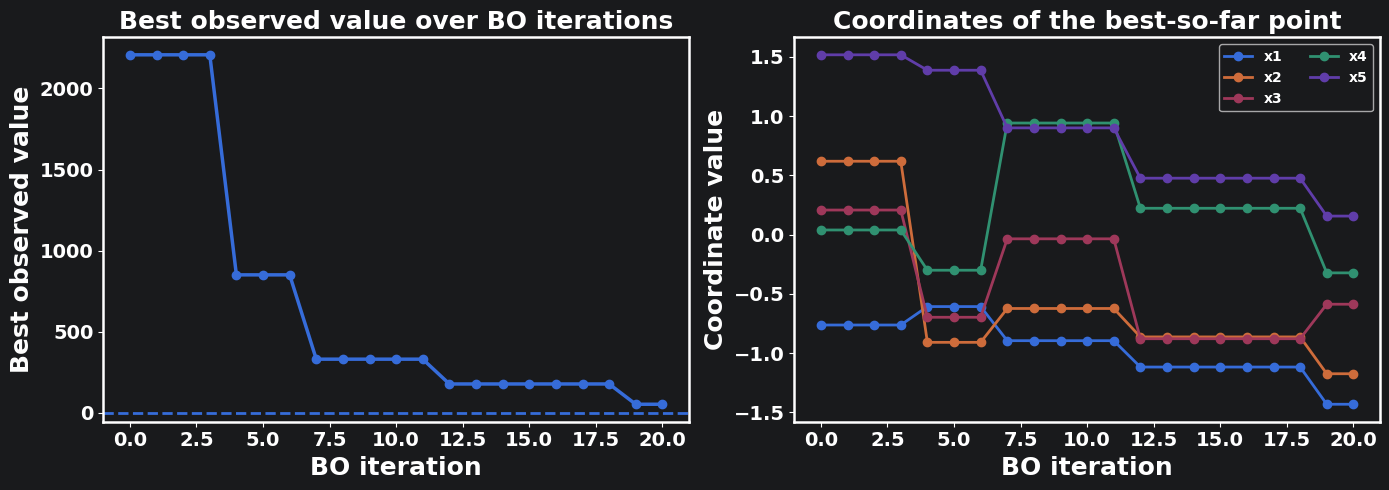

In [8]:
best_vals = [float(h["best_y"]) for h in history]
best_xs = torch.stack([h["best_x"] for h in history], dim=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(best_vals)), best_vals, "-o", linewidth=2.5)
axes[0].axhline(y_opt.item(), linestyle="--", linewidth=2.0, label="Known optimum value")
axes[0].set_title("Best observed value over BO iterations", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=18, fontweight="bold")
axes[0].set_ylabel("Best observed value", fontsize=18, fontweight="bold")
style_ax(axes[0])

for j in range(dim):
    axes[1].plot(
        range(best_xs.shape[0]),
        best_xs[:, j].numpy(),
        "-o",
        linewidth=2.0,
        label=variable_names[j],
    )

axes[1].set_title("Coordinates of the best-so-far point", fontsize=18, fontweight="bold")
axes[1].set_xlabel("BO iteration", fontsize=18, fontweight="bold")
axes[1].set_ylabel("Coordinate value", fontsize=18, fontweight="bold")
axes[1].legend(prop={"size": 10, "weight": "bold"}, ncol=2)
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 8. Tracking the learned GP lengthscales and noise over BO iterations

So far, the BO diagnostics have focused mainly on **what the optimiser is doing externally**:

- how the best observed value improves,
- and how the best-so-far solution changes over time.

This figure looks one level deeper and asks:

> **How is the Gaussian Process surrogate itself changing as new observations are collected?**

That is what the learned:

- **lengthscales**
- and **noise level**

help us understand.

These are internal GP hyperparameters, but they are very useful because they describe how the surrogate is interpreting the structure of the objective.

---

### What the code does

The first two lines extract the stored hyperparameters from `history`:

```python
lengthscales = np.array([h["lengthscale"] for h in history])
noise_vals = [h["noise"] for h in history]
```

So:

- `lengthscales[t, j]` is the learned GP lengthscale for input dimension `j` at BO step `t`
- `noise_vals[t]` is the learned GP likelihood noise at BO step `t`

The code then creates a two-panel figure.

#### Left panel
The left panel plots the learned lengthscale for each coordinate over BO iterations.

#### Right panel
The right panel plots the learned noise over BO iterations.

Together, these plots show how the GP’s internal view of the problem evolves as the BO loop collects more data.

---

### What a GP lengthscale means

The lengthscale controls how quickly the GP expects the function to vary along a given input dimension.

Roughly speaking:

- a **small lengthscale** means the GP believes the function can change quite rapidly as that variable changes
- a **large lengthscale** means the GP believes the function varies more smoothly and slowly along that variable

Because this is a 5-dimensional problem, the GP learns one effective lengthscale per input dimension.

So the left panel tells us how the surrogate’s notion of sensitivity differs across the coordinates.

---

### Why some lengthscales decrease while others increase

This behaviour is entirely reasonable.

The GP is refit at every BO iteration using the current dataset, so the learned lengthscales are not fixed truths.
They are the model’s current best interpretation of the available data.

That means a lengthscale can move in either direction depending on what the new observations suggest.

#### If a lengthscale decreases
This usually means the GP is learning that the objective varies more sharply along that coordinate than it previously thought.

In other words, the model is being pushed toward a view where small changes in that variable can matter a lot.

#### If a lengthscale increases
This usually means the GP is learning that the objective appears smoother or less sensitive along that coordinate than previously believed.

In that case, the model becomes more willing to interpolate over a broader range in that variable.

So a falling lengthscale does **not** mean the model is getting worse, and an increasing lengthscale does **not** mean it is getting better.
They simply reflect the GP adapting its notion of directional smoothness as more data arrive.

---

### Why different coordinates behave differently in the left panel

In the attached result, some coordinates remain fairly small and stable, while others are noticeably larger or move more strongly over time.

This is expected for at least two reasons.

#### 1. Rosenbrock is anisotropic
The Rosenbrock function does not behave identically in every coordinate direction.

Its variables are coupled through terms like

$$
z_{i+1} - z_i^2,
$$

so different dimensions can influence the local geometry in different ways.

That means the GP does not have any reason to learn identical lengthscales for all variables.

#### 2. The BO data are not evenly informative in every direction
As BO proceeds, it samples only a relatively small number of points in a 5D space.

So the evidence the surrogate receives about each coordinate direction is uneven.

Some variables may be probed in a way that makes local variation more obvious, which can drive the corresponding lengthscale downward.
Others may remain comparatively under-resolved, or may look smoother in the sampled region, which can push the lengthscale upward.

So the left-panel diversity is a natural result of:

- anisotropic objective geometry
- plus uneven data support across directions

---

### How to interpret the left panel qualitatively

The most useful way to read the left panel is not to obsess over the exact numerical value of each curve, but to ask questions like:

- Which coordinates consistently have larger learned lengthscales?
- Which coordinates are inferred to be more sensitive?
- Are the lengthscales stabilising over time, or still moving a lot?
- Does the GP appear to be settling into a more coherent directional picture of the objective?

In the attached result, the hyperparameters do not look wildly unstable.
They move, but they do so in a fairly interpretable way.

That is a good sign: it suggests the surrogate is adapting rather than behaving erratically.

---

### What the learned noise means

The right panel shows the learned likelihood noise.

This is the GP’s estimate of how much observational noise is needed to explain the dataset.

Even though the Rosenbrock benchmark itself is deterministic, the GP still fits a noise parameter because:

- `SingleTaskGP` includes a likelihood noise term
- and finite-data surrogate fitting may still prefer a nonzero noise level for numerical and modelling reasons

So the noise curve is best interpreted as:

> the amount of observation-level uncertainty the GP is currently using to explain the data it has seen so far.

---

### Is the right-panel behaviour expected?

Yes — the behaviour in the attached result is very reasonable.

The learned noise starts at a modest positive value and then gradually decreases over BO iterations.

This is exactly the kind of trend we would expect in a deterministic synthetic problem.

#### Why it starts nonzero
At the beginning of the BO run, the GP has only a small number of observations.
With limited data, the surrogate may initially use a somewhat larger noise term to avoid overfitting and to remain flexible.

#### Why it decreases later
As more data are collected, the GP gains a clearer picture of the objective structure.
Since the underlying Rosenbrock function is actually noise-free, the model typically becomes more confident and no longer needs as much observation noise to explain the data.

So the downward trend in the right panel is entirely consistent with the setting.

---

### Should the noise become exactly zero?

Not necessarily.

Even for a deterministic benchmark, the learned GP noise often does **not** go exactly to zero.

That is normal.

The reasons include:

- numerical regularisation
- limited data
- imperfect kernel fit
- and the fact that the GP may still use a small positive noise level as part of a stable surrogate fit

So the important thing is not whether the noise reaches zero exactly, but whether it behaves sensibly.

In this figure, it does:

- it starts somewhat higher
- then decreases as the dataset grows
- and eventually settles at a lower level

That is the expected qualitative pattern.

---

### Why this figure is useful in a high-dimensional BO tutorial

In high-dimensional BO, we cannot inspect the surrogate through full posterior surface plots.

So internal diagnostics like this become more valuable.

They let us see:

- how the GP is learning directional smoothness
- whether some coordinates appear more sensitive than others
- and whether the model is becoming more confident as the BO run proceeds

So this figure is one of the more useful “model-side” diagnostics once direct geometric visualisation is no longer available.

---

### Key takeaway

This figure tracks how the GP surrogate adapts its internal hyperparameters during the BO run.

The **left panel** shows that different coordinates can learn different lengthscales, and that some may decrease while others increase as the model revises its view of directional smoothness and sensitivity.

The **right panel** shows the learned noise gradually decreasing, which is exactly the behaviour we would expect in a deterministic benchmark as the GP becomes better informed by additional data.

So the figure provides a compact view of how the surrogate is evolving internally, even when the full high-dimensional objective cannot be directly visualised.

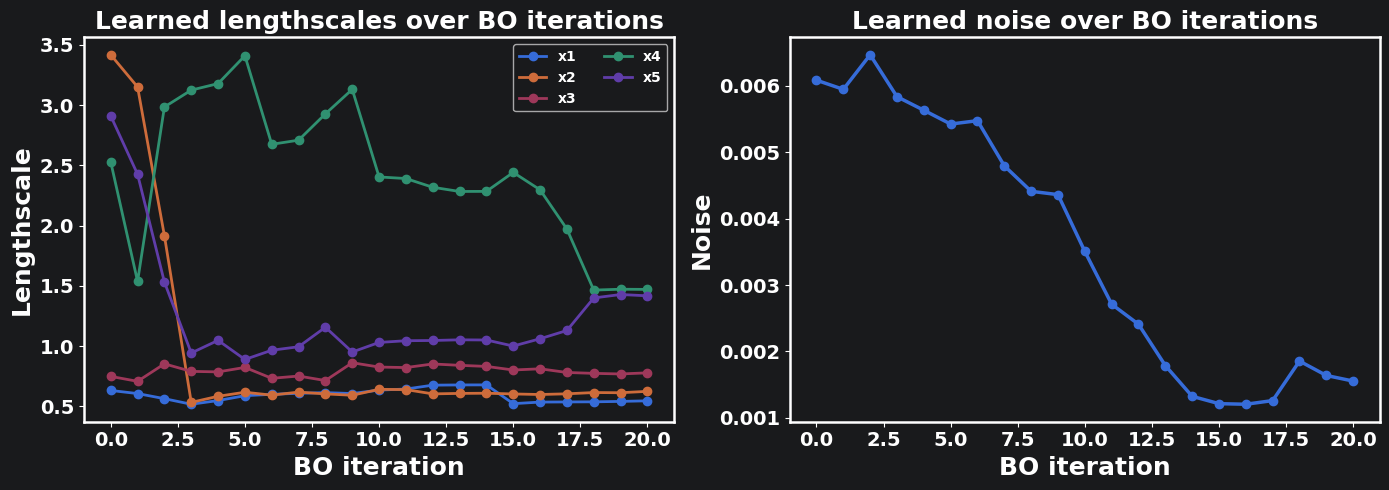

In [9]:
lengthscales = np.array([h["lengthscale"] for h in history])
noise_vals = [h["noise"] for h in history]

n_dims_to_plot = min(dim, 6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(n_dims_to_plot):
    axes[0].plot(
        range(lengthscales.shape[0]),
        lengthscales[:, j],
        "-o",
        linewidth=2.0,
        label=variable_names[j],
    )

axes[0].set_title("Learned lengthscales over BO iterations", fontsize=18, fontweight="bold")
axes[0].set_xlabel("BO iteration", fontsize=18, fontweight="bold")
axes[0].set_ylabel("Lengthscale", fontsize=18, fontweight="bold")
axes[0].legend(prop={"size": 10, "weight": "bold"}, ncol=2)
style_ax(axes[0])

axes[1].plot(range(len(noise_vals)), noise_vals, "-o", linewidth=2.5)
axes[1].set_title("Learned noise over BO iterations", fontsize=18, fontweight="bold")
axes[1].set_xlabel("BO iteration", fontsize=18, fontweight="bold")
axes[1].set_ylabel("Noise", fontsize=18, fontweight="bold")
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 9. Comparing BO behaviour across different input dimensions

So far, the notebook has focused on one specific high-dimensional BO run.

But one of the most important questions in this tutorial is broader:

> **What happens to Bayesian Optimisation when the dimensionality of the search space increases?**

This cell is designed to answer that question in a controlled way.

Instead of changing the BO algorithm itself, we keep the workflow fixed and rerun the same high-dimensional BO procedure for several different dimensions:

- `d = 2`
- `d = 4`
- `d = 8`

This allows us to isolate the effect of **dimension alone** on BO behaviour.

---

### What the code does

The first line defines the dimensions to compare:

```python
dims_to_compare = [2, 4, 8]
```

So the BO workflow will be rerun three times, once for each of these input dimensions.

An empty dictionary is then created:

```python
comparison_histories = {}
```

This is used to store the full BO history for each dimension separately.

---

### How the loop works

The code then loops over each chosen dimension:

```python
for d in dims_to_compare:
```

For each value of `d`, it rebuilds the entire BO problem from scratch:

- new bounds with the correct dimension
- a new Sobol initial design
- a new Rosenbrock objective dataset
- and a new BO run

So this is not reusing the previous 5D run.
It is constructing three fresh optimisation problems of dimensions 2, 4, and 8.

---

### Why `torch.manual_seed(seed)` is used inside the loop

The line

```python
torch.manual_seed(seed)
```

is reset at the start of each dimension-specific run.

This is useful for reproducibility.

It means each BO comparison starts from a controlled random state rather than inheriting the random state from the previous loop iteration.

That does **not** make the runs “identical” across dimensions, because the dimensionality and search space are still different.
But it does make the comparison more consistent and easier to reproduce.

So this is a sensible way to keep the comparison orderly.

---

### Why `bounds_d` is rebuilt for each dimension

The bounds are redefined each time as:

```python
bounds_d = torch.tensor(
    [[lower_bound] * d, [upper_bound] * d],
    dtype=torch.double,
)
```

This ensures that each BO run has a valid search box of shape:

```python
(2, d)
```

So:

- when `d = 2`, the search region is $[-2, 2]^2$
- when `d = 4`, the search region is $[-2, 2]^4$
- when `d = 8`, the search region is $[-2, 2]^8$

This is important because the BO loop and the Sobol initial design must both know the correct input dimensionality.

---

### Why `n_init_d = 2 * d` is used

The initial design size is scaled with dimension:

```python
n_init_d = 2 * d
```

So each dimensional setting gets an initial Sobol design proportional to the number of variables.

This keeps the comparison somewhat fairer than using the same fixed number of initial points across all dimensions.

For example:

- `d = 2` gets 4 initial points
- `d = 4` gets 8 initial points
- `d = 8` gets 16 initial points

This is still a modest initial budget, but it respects the idea that higher-dimensional spaces generally require somewhat larger initial coverage.

---

### Why a fresh Sobol design is generated for each dimension

The code then creates the initial data:

```python
train_X_d = draw_sobol_samples(bounds=bounds_d, n=1, q=n_init_d).squeeze(0)
train_Y_d = objective_rosenbrock(train_X_d)
```

So for each dimension:

- a fresh Sobol initial design is generated
- the Rosenbrock objective is evaluated on it
- and that becomes the starting dataset for the BO loop

This is important because the search space itself changes with `d`, so both the initial dataset and the objective values must be regenerated accordingly.

---

### What `history_d` represents

The main BO run is then executed:

```python
history_d = run_high_dim_bo_loop(
    train_X_init=train_X_d,
    train_Y_init=train_Y_d,
    objective_fn=objective_rosenbrock,
    bounds=bounds_d,
    n_steps=30,
    num_restarts=20,
    raw_samples=256
)
```

This produces the full sequential BO history for that particular dimensionality.

So `history_d` contains everything the notebook later needs in order to compare BO performance across dimensions, including:

- observed datasets over time
- best values
- best points
- learned lengthscales
- and learned noise

The final line stores that history in the dictionary:

```python
comparison_histories[d] = history_d
```

So at the end of the cell, `comparison_histories` contains one BO run for each chosen dimensionality.

---

### Why this comparison is useful

This cell is one of the most important in the notebook conceptually.

It directly addresses a core high-dimensional BO question:

> **How does optimisation difficulty change as the number of input variables increases?**

By rerunning the same workflow across multiple dimensions, we can later compare:

- best observed values
- convergence speed
- and general optimisation difficulty

This is much more informative than looking at one single BO run in isolation.

---

### Why a `RuntimeWarning` can appear here

When this cell is run, you may sometimes see a warning like:

```python
RuntimeWarning: Optimization failed in `gen_candidates_scipy` ...
Trying again with a new set of initial conditions.
```

This warning comes from the **inner acquisition optimisation step**, not from the objective itself and not from the BO loop as a whole.

More specifically, at each BO iteration BoTorch must solve a separate numerical optimisation problem:

> maximise the acquisition function over the bounded search space

That inner optimisation is done using SciPy-based local optimisation from multiple starting points.
In higher dimensions, this can become significantly harder.

So the warning typically means:

- one particular local optimisation attempt failed to converge cleanly
- or one restart ended with an abnormal optimiser status
- and BoTorch is automatically retrying with different initial conditions

This is why the warning message explicitly says that it is:

- **trying again with a new set of initial conditions**

So the important point is:

> this warning does **not** usually mean that the whole BO run has failed.

It usually means only that one acquisition-optimisation attempt was numerically awkward.

---

### Why the warning is more likely in this cell

This warning is more likely to appear here than in simpler earlier cells because this comparison increases the difficulty of the acquisition optimisation problem.

In particular:

#### 1. Higher dimensions make the acquisition landscape harder to optimise
For `d = 8`, the acquisition function is being optimised in a much larger search space than for `d = 2`.

That makes local optimisation more fragile and increases the chance of unlucky starting conditions.

#### 2. `raw_samples=256` and `num_restarts=20` mean many optimisation attempts are being launched
This is good for robustness overall, but it also means there are simply more individual SciPy optimisation runs that could trigger a warning.

#### 3. The Rosenbrock benchmark itself induces nontrivial surrogate structure
That can lead to a more irregular acquisition landscape, which again makes the inner optimisation problem less easy.

So the warning is not surprising in a high-dimensional BO comparison.
It is a side effect of solving many difficult acquisition-subproblems.

---

### Should the warning worry us?

Usually, not very much.

If the BO run continues and produces sensible results, then the warning should be interpreted as:

- a numerical caution,
- not a full algorithmic failure.

In many cases, BoTorch successfully recovers by restarting from better initial conditions.

So the practical rule is:

- **occasional warnings are acceptable**
- especially in higher-dimensional acquisition optimisation
- as long as the resulting BO behaviour remains sensible and reproducible

What would be more concerning is if:

- the warnings happen constantly,
- the BO results become obviously erratic,
- or the optimisation fails to return candidates reliably

But occasional warnings in this kind of comparison are quite normal.

---

### What this says about high-dimensional BO more generally

This warning is actually a useful teaching point.

It reinforces that high-dimensional BO is not difficult only because the objective is harder.
It is also difficult because the **inner acquisition optimisation problem** becomes harder.

So as dimension grows, BO faces two challenges at once:

- modelling the objective with limited data
- and reliably optimising the acquisition function itself

This is part of why high-dimensional BO becomes substantially more delicate than low-dimensional BO.

---

### Key takeaway

This cell reruns the same BO workflow across dimensions 2, 4, and 8 in order to compare how BO behaviour changes as the search space becomes higher-dimensional.

The resulting histories are stored in `comparison_histories` for later analysis.

If a `RuntimeWarning` appears, it usually means that one of the inner SciPy-based acquisition-optimisation attempts failed to converge cleanly and BoTorch is retrying with different starting points.

In this context, that is usually a **numerical warning rather than a fatal BO failure**, and it is more likely to appear precisely because higher-dimensional acquisition optimisation is harder.

In [10]:
dims_to_compare = [2, 4, 8]
comparison_histories = {}

for d in dims_to_compare:
    torch.manual_seed(seed)

    bounds_d = torch.tensor(
        [[lower_bound] * d, [upper_bound] * d],
        dtype=torch.double,
    )

    n_init_d = 2 * d

    train_X_d = draw_sobol_samples(bounds=bounds_d, n=1, q=n_init_d).squeeze(0)
    train_Y_d = objective_rosenbrock(train_X_d)

    history_d = run_high_dim_bo_loop(
        train_X_init=train_X_d,
        train_Y_init=train_Y_d,
        objective_fn=objective_rosenbrock,
        bounds=bounds_d,
        n_steps=30,
        num_restarts=20,
        raw_samples=256
    )

    comparison_histories[d] = history_d

/Users/liangze/Desktop/PyTorch/.venv1/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)
/Users/liangze/Desktop/PyTorch/.venv1/lib/python3.12/site-packages/botorch/optim/optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


## 10. Comparing BO performance across dimensions on a log scale

One of the main purposes of this tutorial is to show that a BO workflow can be written in a way that is **dimension-customisable**.

But once that has been achieved, the next question becomes:

> **How does BO behaviour change as the dimension of the search space increases?**

This figure is designed to answer that question directly.

It compares the best observed value achieved by the same BO workflow when the input dimension is:

- `d = 2`
- `d = 4`
- `d = 8`

and plots those trajectories on a **logarithmic y-scale**.

This is a particularly useful way to visualise the comparison, because the objective values in different dimensions can differ by very large factors.

---

### What the code does

The code begins with:

```python
eps = 1e-6
```

This small positive number is added to the best observed values before plotting.

That is necessary because the y-axis is later set to logarithmic scale:

```python
ax.set_yscale("log")
```

and logarithmic axes cannot represent zero exactly.

So `eps` acts as a tiny numerical safeguard that ensures the plotted values remain strictly positive.

---

### How the per-dimension curves are built

For each dimension stored in `comparison_histories`, the code extracts:

```python
best_vals_d = [float(torch.min(h["train_Y"])) for h in hist]
```

This gives the best observed objective value over BO iterations for that particular dimensionality.

The code also computes:

```python
x_opt_d = torch.linspace(-1.5, 1.5, d, dtype=torch.double).unsqueeze(0)
y_opt_d = objective_rosenbrock(x_opt_d).item()
```

and

```python
simple_regret_d = [float(torch.min(h["train_Y"]) - y_opt_d) for h in hist]
```

Although `simple_regret_d` is defined here, it is not actually used in the plot.
The displayed figure uses the **best observed values** themselves.

So the final plotted curves are:

```python
np.array(best_vals_d) + eps
```

for each dimension.

---

### Why the y-axis is logarithmic

Using a linear y-axis would make this figure much harder to read.

That is because higher-dimensional runs often begin at much larger objective values and may remain much farther from low objective regions than lower-dimensional runs.

If all curves were shown on a linear scale, the highest-dimensional one could dominate the vertical range and compress the lower-dimensional curves near the bottom of the plot.

A logarithmic y-axis solves this problem by making multiplicative differences easier to compare.

So the log scale is used here because it allows us to see:

- early large differences,
- later smaller differences,
- and cross-dimensional trends

within the same figure much more clearly.

---

### How to read the figure

Each curve answers the question:

> *For this dimensionality, what is the best objective value BO has found after each iteration?*

Since this is a minimisation problem:

- lower curves indicate better performance
- downward drops indicate the discovery of a new best point
- flat regions indicate that BO has not improved on the current best solution yet

So the figure compares not just final performance, but also the **speed and difficulty of improvement** across dimensions.

---

### Why higher dimension means harder optimisation

The main lesson of this figure is that, in general:

> **higher-dimensional BO is harder than lower-dimensional BO under the same general workflow and comparable budgets.**

This happens for several related reasons.

#### 1. The search space grows rapidly with dimension
As the number of input variables increases, the volume of the search region grows dramatically.

Even though each coordinate still lies in the same interval, the full space becomes much larger.
That means a fixed number of evaluations gives much weaker coverage of the domain.

So in higher dimensions, the optimiser is effectively trying to learn a much larger problem from a still-limited dataset.

---

#### 2. The surrogate must infer a more complex function from sparse data
A Gaussian Process does not directly observe the whole objective surface.
It only sees a finite set of sampled points.

When the number of dimensions increases, the same number of observations becomes much less informative relative to the size of the domain.

So the GP has a harder job:

- it must infer directional sensitivities across more coordinates
- and it must do so with data that are much more sparse in the high-dimensional space

This makes surrogate uncertainty more difficult to reduce effectively.

---

#### 3. The acquisition function becomes harder to optimise
Higher-dimensional BO is not difficult only because the objective is harder.

It is also difficult because the **inner optimisation problem** becomes harder.

At every BO iteration, the acquisition function must itself be maximised over the full bounded design space.

As dimension increases:

- the acquisition landscape lives in a larger space
- local optimisation becomes more fragile
- and it becomes easier to miss good candidate regions

So high-dimensional BO is harder both on the modelling side and on the acquisition-optimisation side.

---

#### 4. Useful regions occupy a smaller fraction of the space
For many objectives, including Rosenbrock, the truly good regions are geometrically small relative to the full search domain.

As dimension increases, this issue becomes more severe.

That means BO has to identify a narrow useful region inside a much larger ambient space, and doing that with limited evaluations becomes increasingly difficult.

---

### What this means in practice

This is exactly why higher-dimensional BO should not be interpreted as simply “the same thing but with more coordinates.”

The optimisation problem changes qualitatively.

A workflow that looks highly effective in:

- 2D

may become much slower or less decisive in:

- 4D
- 8D
- or higher

even if the same BO code is used.

So the purpose of this figure is not just to compare three benchmark runs.
It is to make the core practical point that:

> **dimension itself is a major source of BO difficulty.**

---

### Why this matters for real experimental optimisation

This lesson is especially important in realistic experimental problems.

If a design space contains:

- temperature,
- concentration,
- pH,
- catalyst loading,
- reaction time,
- precursor ratio,
- and several other controllable settings,

then the BO problem quickly becomes genuinely high-dimensional.

In such settings, a limited experiment budget may be enough to make progress, but it is usually not enough to fully characterise the whole design space.

So this figure provides a useful bridge from synthetic benchmark intuition to real applied BO reasoning.

It helps explain why, in practice, higher-dimensional BO often needs:

- stronger prior knowledge,
- tighter bounds,
- better initial design,
- batch experimentation,
- or more structured modelling assumptions.

---

### Why this figure is more useful than direct geometric visualisation

In 2D, we might have tried to understand BO by plotting the objective surface directly.

In 8D, that is no longer possible.

So a cross-dimensional performance figure like this becomes one of the most useful ways to understand how BO scales.

It shows:

- how quickly improvement happens
- how much performance differs across dimension
- and how the optimisation budget becomes less effective as dimension grows

That makes it one of the central summary plots of the notebook.

---

### Key takeaway

This figure compares the best observed value achieved by BO across dimensions `2`, `4`, and `8`, using a logarithmic y-axis so that the trajectories remain visually comparable.

The main lesson is:

> **as the dimensionality increases, BO generally becomes harder.**

This is because higher dimensions make the search space larger, the surrogate problem sparser, the acquisition optimisation harder, and the good regions more difficult to identify within a limited evaluation budget.

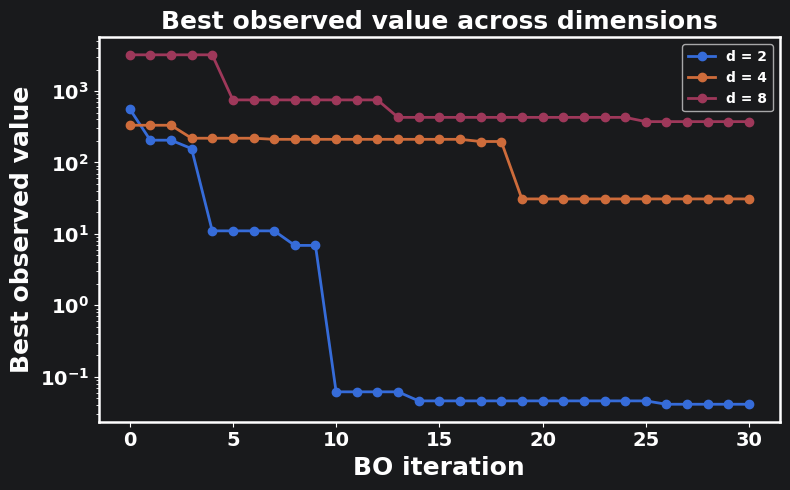

In [11]:
eps = 1e-6

fig, ax = plt.subplots(figsize=(8, 5))

for d, hist in comparison_histories.items():
    x_opt_d = torch.linspace(-1.5, 1.5, d, dtype=torch.double).unsqueeze(0)
    y_opt_d = objective_rosenbrock(x_opt_d).item()

    best_vals_d = [float(torch.min(h["train_Y"])) for h in hist]
    simple_regret_d = [float(torch.min(h["train_Y"]) - y_opt_d) for h in hist]

    ax.plot(range(len(best_vals_d)), np.array(best_vals_d) + eps, "-o", linewidth=2.0, label=f"d = {d}")

ax.set_title("Best observed value across dimensions", fontsize=18, fontweight="bold")
ax.set_xlabel("BO iteration", fontsize=18, fontweight="bold")
ax.set_ylabel("Best observed value", fontsize=18, fontweight="bold")
ax.set_yscale("log")
style_ax(ax)
ax.legend(prop={"size": 10, "weight": "bold"})

plt.tight_layout()
plt.show()

## 11. Wrapping the high-dimensional BO workflow into a user-facing function

At this point in the notebook, we already have a working high-dimensional BO engine:

```python
run_high_dim_bo_loop(...)
```

That function is the core optimisation routine, and it is still essential.

However, it is a **lower-level function**.
It assumes that several things have already been prepared manually, including:

- the initial design `train_X_init`
- the initial observations `train_Y_init`
- the bounds tensor
- and the rest of the BO configuration

For a tutorial, that is useful because it makes the BO mechanics transparent.

But for a **real reusable workflow**, it is not yet convenient enough.

That is why this cell introduces:

```python
run_custom_high_dim_bo(...)
```

This new function is a **higher-level wrapper** that turns the earlier BO machinery into a more ready-to-use interface for real multidimensional optimisation problems.

---

### What this function is doing

The function `run_custom_high_dim_bo(...)` takes a more user-friendly set of inputs:

- a custom objective function
- a bounds tensor
- the number of initial points
- the number of BO steps
- optional variable names
- acquisition-optimisation settings
- and an optional random seed

Then it automatically performs the setup and execution steps that we previously had to do manually:

1. set the random seed if requested
2. infer the input dimension from `bounds`
3. create default variable names if none are provided
4. generate a Sobol initial design
5. evaluate the objective on that initial design
6. call the lower-level BO loop
7. extract the final best point and best value
8. return everything in a clean results dictionary

So this is the point where the notebook stops being only a worked example and becomes a reusable template.

---

## What the improvements are

Compared with using `run_high_dim_bo_loop(...)` directly, this wrapper introduces several clear improvements.

### 1. The user no longer needs to prepare the initial dataset manually

Previously, before calling the BO loop, we had to manually write code to generate:

- `train_X`
- and `train_Y`

using a Sobol design and an objective evaluation.

This new wrapper does that automatically:

```python
train_X = draw_sobol_samples(bounds=bounds, n=1, q=n_init).squeeze(0)
train_Y = objective_fn(train_X)
```

That makes the workflow much easier to reuse.

---

### 2. The dimensionality is inferred automatically from the bounds

Instead of passing `dim` explicitly, the function computes:

```python
dim = bounds.shape[-1]
```

This is a useful improvement because it reduces bookkeeping and helps keep the interface cleaner.

The dimensionality now follows directly from the problem definition.

---

### 3. Default variable names are created automatically

If the user does not provide names, the function generates:

```python
x1, x2, ..., xd
```

This means the returned results are immediately easier to inspect and print, even in a generic setting.

---

### 4. The BO workflow becomes closer to a real user API

With the lower-level function, the user had to think in terms of internal BO objects:

- initial tensors
- prepared observations
- engine calls

With this wrapper, the workflow is closer to what a real user would want:

> “Here is my objective, here are my bounds, here is my budget — now run BO.”

That is a major usability improvement.

---

### 5. The final best point and best value are extracted automatically

Previously, after running the BO loop, we still had to manually write code to recover:

- the final observed dataset
- the best point
- and the best value

This wrapper does that for the user and returns them directly as:

- `best_x`
- `best_y`

So the function gives a much cleaner final output.

---

### 6. The return object is more practical for downstream use

Instead of returning only the history, the wrapper returns a structured dictionary containing:

- the full BO history
- the final observed dataset
- the best point found
- the best value found
- the variable names
- the bounds
- and the inferred dimension

This makes the function much more convenient for later plotting, printing, or integration into a real optimisation workflow.

---

## Why we still need the old function

Even though this wrapper is more convenient, we still absolutely need the earlier function:

```python
run_high_dim_bo_loop(...)
```

because it is the **actual BO engine** used internally here.

This new wrapper does **not** replace the old function.
Instead, it builds on top of it.

The core BO step-by-step logic still lives in:

```python
history = run_high_dim_bo_loop(...)
```

inside the wrapper.

So the relationship is:

- `run_high_dim_bo_loop(...)` = the lower-level reusable optimisation engine
- `run_custom_high_dim_bo(...)` = the higher-level user-facing wrapper built on top of that engine

That is why the older function must still remain in the notebook.

Without it, this wrapper would have no BO loop to call.

---

## Why this design is good practice

This two-layer structure is actually a very good software design pattern.

It separates the workflow into:

### A lower-level engine
This handles the actual BO mechanics:

- GP fitting
- acquisition construction
- acquisition optimisation
- sequential updating
- history storage

### A higher-level interface
This handles usability:

- initial design generation
- configuration defaults
- result packaging
- and real-world convenience

That separation makes the code:

- easier to understand
- easier to debug
- easier to reuse
- and easier to adapt later

So this is not just a convenience change.
It is a structurally cleaner design.

---

## Why this matters for the end of the notebook

This cell is important because it marks the transition from:

- a tutorial that shows **how the BO workflow works**
- to a template that a user could actually **take away and reuse**

That is exactly the right way to end a notebook like this.

The earlier cells build understanding.
This function packages that understanding into something directly usable.

So this is the point where the notebook becomes not only explanatory, but also practically deployable.

---

### Key takeaway

`run_custom_high_dim_bo(...)` is a higher-level wrapper that turns the earlier high-dimensional BO machinery into a more user-friendly and reusable interface.

Its main improvements are:

- automatic Sobol initialisation
- automatic objective evaluation on the initial design
- automatic dimension inference from bounds
- automatic default variable naming
- automatic extraction of the final best point and best value
- and a cleaner, more practical return object

However, we still need the older function `run_high_dim_bo_loop(...)`, because that function remains the actual BO engine used internally by this wrapper.
So the new function is an improvement in usability, not a replacement of the core BO logic.

## 11. Comparing BO behaviour under different evaluation budgets

So far, the notebook has shown how to build and analyse a high-dimensional BO workflow for one fixed optimisation budget.

But in realistic optimisation problems, one of the most important practical questions is not just:

> **How does BO behave in higher dimensions?**

It is also:

> **How much does the available evaluation budget affect what BO is able to achieve?**

This cell is designed to answer that question directly.

Instead of changing the objective, bounds, or BO algorithm, we keep the optimisation problem fixed and vary only the amount of budget available to the BO loop.

That lets us isolate the effect of:

- the number of initial evaluations
- and the number of sequential BO updates

on the final optimisation outcome.

---

### What the code does

The cell defines three budget settings:

```python
budget_settings = {
    "Small budget": {"n_init": 8, "n_steps": 8},
    "Medium budget": {"n_init": 10, "n_steps": 20},
    "Larger budget": {"n_init": 16, "n_steps": 40},
}
```

These correspond to three different BO regimes:

- a **small budget**, with relatively few initial points and relatively few BO updates
- a **medium budget**, which allows more sequential improvement
- a **larger budget**, which gives BO substantially more opportunity to refine the search

So the comparison here is not about changing the underlying optimisation problem.
It is about asking how the **same BO workflow** behaves when it is allowed to spend different amounts of evaluation budget.

---

### Why both `n_init` and `n_steps` change

Each budget setting changes both:

- the size of the initial Sobol design
- and the number of BO iterations

This is deliberate.

In a real workflow, a larger total budget usually does not only mean “more BO iterations after the same start.”
It often also means that we can afford a slightly stronger initial design before the sequential stage begins.

So these budget settings should be interpreted as three increasingly well-funded BO workflows:

- smaller initial information + fewer sequential decisions
- moderate initial information + more sequential decisions
- larger initial information + more sequential decisions

That makes the comparison more realistic than varying only one of these quantities in isolation.

---

### Why `budget_histories` is used

The dictionary

```python
budget_histories = {}
```

is used to store the full BO history for each budget level.

That way, the notebook can later compare:

- best observed value over time
- final performance
- and possibly final best-found solutions

for each budget setting separately.

So this is the same general structure used earlier for the cross-dimensional comparison, but now the varying factor is **budget** rather than **dimension**.

---

### Why the random seed is reset inside the loop

Inside the loop, the code uses:

```python
torch.manual_seed(seed)
```

at the start of each budget condition.

This is a good practice for reproducibility and consistency.

It ensures that each budget comparison starts from a controlled random state rather than inheriting randomness from previous runs.

That does **not** make the three budget settings identical, because:

- their `n_init` values differ
- and their BO trajectories are still different

But it does make the comparison cleaner and more repeatable.

So this is a sensible way to reduce accidental randomness in the setup.

---

### How the initial dataset is generated for each budget

For each budget level, the code creates a fresh Sobol initial design:

```python
train_X_budget = draw_sobol_samples(
    bounds=bounds,
    n=1,
    q=config["n_init"],
).squeeze(0)
train_Y_budget = objective_rosenbrock(train_X_budget)
```

This means each budget setting starts from its own initial dataset, sized according to its allocated `n_init`.

So:

- the small-budget run begins from fewer initial observations
- the larger-budget run begins from a somewhat richer initial design

This is one reason the later budget comparison is meaningful: the quality of the initial surrogate itself is part of what the budget is buying.

---

### How the BO loop is reused here

The actual BO run for each budget level is performed by calling the same reusable engine:

```python
history_budget = run_high_dim_bo_loop(
    train_X_init=train_X_budget,
    train_Y_init=train_Y_budget,
    objective_fn=objective_rosenbrock,
    bounds=bounds,
    n_steps=config["n_steps"],
    num_restarts=20,
    raw_samples=256,
)
```

This is important.

The BO algorithm is not being changed across the three runs.

The same high-dimensional BO workflow is used every time:

- same objective
- same search bounds
- same acquisition-optimisation settings
- same GP modelling choices

Only the **evaluation budget** changes.

So any later difference in optimisation performance can be interpreted mainly as a consequence of how much budget BO was allowed to spend.

---

### Why this comparison is useful

This cell addresses a very practical question.

In real optimisation settings, especially experimental ones, the main constraint is often not theory but budget:

- how many experiments can be run
- how much time is available
- how many candidate conditions can be tested
- how many total objective evaluations can be afforded

So this comparison helps answer:

> **What does a small budget buy us, and what does a larger budget buy us?**

That is one of the most useful practical questions in high-dimensional BO.

---

### Why this matters especially in higher dimensions

Budget sensitivity becomes more important as the dimensionality increases.

In a low-dimensional problem, even a modest number of evaluations may be enough for BO to build a useful surrogate and identify strong regions of the search space.

In a higher-dimensional problem, that becomes much harder.

The same budget must now cover:

- a larger design space
- more coordinate directions
- more uncertain surrogate structure
- and a harder acquisition-optimisation problem

So it is especially important to study budget effects in a tutorial like this one.

This is one of the clearest ways to connect the synthetic example to real optimisation practice.

---

### What this sets up for the next figure

After this cell, `budget_histories` contains one full BO run for each budget setting.

That means the notebook can now compare:

- how quickly each budget level improves
- how far each budget level gets
- and how strongly additional evaluations change the optimisation outcome

This is a very natural final analytical direction for the notebook, because it moves from:

- *how to build high-dimensional BO*
- to
- *how budget changes what high-dimensional BO can realistically achieve*

---

### Key takeaway

This cell reruns the same high-dimensional BO workflow under three different evaluation budgets:

- small
- medium
- and larger

Each budget changes both:

- the size of the initial Sobol design
- and the number of BO iterations

The goal is to isolate the practical effect of evaluation budget on high-dimensional BO performance, which is one of the most important real-world considerations in expensive optimisation problems.

In [12]:
budget_settings = {
    "Small budget": {"n_init": 8, "n_steps": 8},
    "Medium budget": {"n_init": 10, "n_steps": 20},
    "Larger budget": {"n_init": 16, "n_steps": 40},
}

budget_histories = {}

for label, config in budget_settings.items():
    torch.manual_seed(seed)

    train_X_budget = draw_sobol_samples(
        bounds=bounds,
        n=1,
        q=config["n_init"],
    ).squeeze(0)
    train_Y_budget = objective_rosenbrock(train_X_budget)

    history_budget = run_high_dim_bo_loop(
        train_X_init=train_X_budget,
        train_Y_init=train_Y_budget,
        objective_fn=objective_rosenbrock,
        bounds=bounds,
        n_steps=config["n_steps"],
        num_restarts=20,
        raw_samples=256,
    )

    budget_histories[label] = history_budget

## 12. Visualising BO performance under different evaluation budgets

After running the same high-dimensional BO workflow under several budget settings, we now want to compare the outcomes directly.

This figure shows how the **best observed value** evolves when BO is given:

- a **small budget**
- a **medium budget**
- and a **larger budget**

The purpose of the plot is to make one practical question visually explicit:

> **How much does the available evaluation budget affect what high-dimensional BO can achieve?**

This is an especially important question in realistic experimental optimisation, where the total number of evaluations is often tightly limited by time, money, materials, or instrumentation.

---

### What the code does

For each stored budget condition in `budget_histories`, the code extracts:

```python
best_vals_budget = [float(torch.min(h["train_Y"])) for h in hist]
```

This gives the best objective value found so far at every BO step for that particular budget setting.

So each curve is a cumulative best-value trajectory.

The code also computes:

```python
total_evals = hist[-1]["train_X"].shape[0]
```

which gives the total number of evaluations used by that budget condition, including:

- the initial Sobol design
- and all subsequent BO-selected points

That total is then included in the legend so that the reader can immediately see how much budget each curve corresponds to.

---

### Why `eps = 1e-6` is included

The line

```python
eps = 1e-6
```

adds a very small positive number to the plotted values:

```python
np.array(best_vals_budget) + eps
```

This is often used when one wants the plot to remain numerically safe even if some values become extremely small.

In the current version of the code, the y-axis is still linear, so this epsilon does not materially change the visual result.
It simply keeps the plotting setup compatible with possible later use of a logarithmic y-scale.

So here it is best interpreted as a harmless numerical safeguard.

---

### How to read the figure

The horizontal axis is:

- **BO iteration**

The vertical axis is:

- **best observed value**

So each point on a curve answers:

> *After this many BO iterations, what is the lowest objective value found so far under this budget setting?*

Because this is a minimisation problem:

- lower is better
- downward jumps indicate genuine improvement
- flat regions indicate that recent BO evaluations did not beat the current best value

So each curve shows how much progress BO is making under a particular total budget.

---

### Why the curves have different lengths

The three budget settings use different values of `n_steps`, so the curves naturally run for different numbers of BO iterations.

That is expected.

The small-budget run ends earlier because it simply has fewer BO updates available.
The larger-budget run continues longer because it has more sequential opportunities to improve.

So the differing curve lengths are not a plotting issue.
They are part of the point of the comparison.

---

### What this plot is showing conceptually

This figure is not asking whether one BO algorithm is better than another.

The algorithm is the same in all three cases.

Instead, it is showing how the *same* BO workflow behaves when it is allowed to spend different amounts of evaluation budget.

That makes the plot especially useful because it isolates the role of budget itself.

In other words, this is a comparison of:

- **same method**
- **same objective**
- **same search space**
- **same modelling setup**
- **different available budget**

That is a very realistic practical question.

---

### How to interpret the expected behaviour

In a higher-dimensional BO problem, a larger budget usually helps for two main reasons:

#### 1. More initial points improve the starting surrogate
A larger `n_init` means the GP begins with a better initial view of the design space.

That can already improve the quality of the early acquisition decisions.

#### 2. More BO iterations give more chances to discover strong regions
A larger `n_steps` gives the optimiser more opportunities to:

- explore uncertain areas
- refine promising regions
- and eventually find substantially better points

So if the larger-budget curve ends lower than the small-budget one, that is exactly the kind of result we would expect.

---

### Why this matters especially in higher dimensions

Budget sensitivity is much stronger in high-dimensional BO than in low-dimensional BO.

In a 2D problem, even a modest number of evaluations may be enough to get a rough but useful picture of the objective.

In a 5D or 8D problem, the same number of evaluations covers only a tiny fraction of the design space.

So small budgets can easily lead to BO runs that:

- identify only moderately good regions
- plateau early
- or fail to reach the truly strongest basin

By contrast, larger budgets may allow BO to continue long enough to make several major improvements.

That is why this figure is such a useful final diagnostic in this notebook.

---

### Why the plot is practically meaningful

This is one of the most realistic BO comparisons in the notebook.

In real experimental optimisation, the main question is often not:

- “Can BO eventually find the global optimum if we run it forever?”

but rather:

- “Given the number of runs I can actually afford, how much progress should I realistically expect?”

This figure speaks directly to that question.

It makes the trade-off between:

- limited budget
- and achievable optimisation quality

visible in a concrete way.

---

### What this figure can help the reader conclude

A figure like this helps the reader see that:

- high-dimensional BO is often **budget-limited**
- the same workflow may look only moderately successful under a small budget
- and a larger budget can unlock substantially better solutions

So the lesson is not simply “more budget is better.”
It is more practically:

> **in higher-dimensional BO, budget can strongly determine whether the optimiser merely finds acceptable regions or actually reaches genuinely strong ones.**

That is an important conclusion for real applied BO.

---

### Why this is a good final analytical direction for the notebook

The earlier parts of the notebook showed:

- how to define the problem
- how to generate the initial design
- how to build the BO loop
- how to analyse the best-so-far point
- and how performance degrades with dimension

This budget comparison complements those results by showing a second major practical constraint:

- not only does dimension matter
- but **budget also matters enormously**

That makes this figure a strong near-final plot for the notebook, because it connects the synthetic benchmark directly to the real economics of expensive optimisation.

---

### Key takeaway

This figure compares the best observed value achieved by the same high-dimensional BO workflow under three different evaluation budgets.

Each curve shows how the best solution found so far evolves over BO iterations, while the legend reports the corresponding total number of evaluations.

The main lesson is:

> **in high-dimensional Bayesian Optimisation, the available evaluation budget strongly affects how far the optimiser can progress.**

Small budgets may identify only moderately good regions, while larger budgets can allow BO to continue refining the search and discover much better solutions.

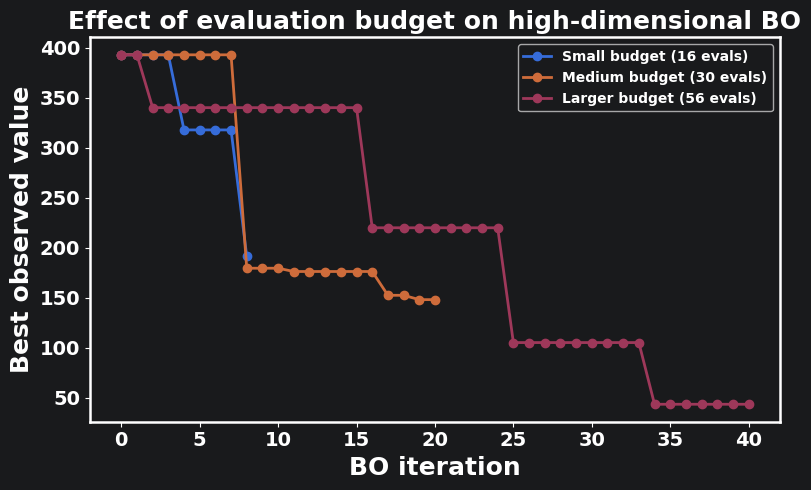

In [13]:
eps = 1e-6

fig, ax = plt.subplots(figsize=(8, 5))

for label, hist in budget_histories.items():
    best_vals_budget = [float(torch.min(h["train_Y"])) for h in hist]
    total_evals = hist[-1]["train_X"].shape[0]

    ax.plot(
        range(len(best_vals_budget)),
        np.array(best_vals_budget) + eps,
        "-o",
        linewidth=2.0,
        label=f"{label} ({total_evals} evals)",
    )

ax.set_title("Effect of evaluation budget on high-dimensional BO", fontsize=18, fontweight="bold")
ax.set_xlabel("BO iteration", fontsize=18, fontweight="bold")
ax.set_ylabel("Best observed value", fontsize=18, fontweight="bold")
style_ax(ax)
ax.legend(prop={"size": 10, "weight": "bold"})

plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from **low-dimensional, directly visualisable Bayesian Optimisation** to the problem of running BO in a **genuinely higher-dimensional design space**.

The central idea was that once the number of input variables becomes large enough, the challenge is no longer only:

- how to fit a surrogate,
- how to build an acquisition function,
- and how to repeat the BO loop,

but also:

- how to define the optimisation problem in a scalable way,
- how to initialise the search sensibly,
- how to diagnose BO progress when the full landscape can no longer be plotted,
- and how to think about evaluation budget in a realistic way.

At a structural level, the BO workflow itself did not change.

We still followed the same core loop:

1. generate an initial dataset,
2. fit a Gaussian Process surrogate,
3. construct an acquisition function,
4. optimise it to select the next evaluation point,
5. evaluate the objective there,
6. update the dataset,
7. and repeat.

What changed in this notebook was the **setting in which that loop was applied**.

That shift was the whole point.

Instead of treating BO as something that is naturally understood through 1D and 2D figures, we treated it as something that must still function when the input space is too large for direct geometric intuition.

That is much closer to the way BO appears in real research problems.

Across the notebook, we used a dimension-customisable Rosenbrock benchmark to make this shift concrete.

This gave us a problem that was still mathematically controlled, but already difficult enough to reveal the main practical difficulties of higher-dimensional BO:

- the search space expands rapidly,
- useful regions become harder to locate with limited data,
- the surrogate must learn from increasingly sparse observations,
- and the acquisition optimisation itself becomes more difficult.

So one of the main lessons of the notebook was that:

> higher-dimensional BO is not simply “the same BO as before, but with more variables.”

It is a more difficult optimisation problem both statistically and numerically.

The early sections of the notebook showed how to build the workflow in a way that still scales with dimension.

That included:

- defining a dimension-customisable objective,
- using a Sobol initial design instead of hand-picked points,
- writing a reusable BO loop that infers dimensionality from the data,
- and storing histories that make later diagnostics possible.

That was an important conceptual step, because once the design space becomes genuinely multidimensional, manual and ad hoc BO code stops being practical very quickly.

The diagnostics we used also reflected this shift.

In lower-dimensional notebooks, BO could often be understood mainly through direct plots of:

- the true objective,
- the posterior mean,
- and the acquisition function.

Here, that was no longer the right approach.

Instead, the notebook focused on diagnostics that remain meaningful in realistic higher-dimensional settings, such as:

- best observed value over iterations,
- coordinate traces of the best-so-far point,
- learned GP lengthscales and noise,
- and comparisons across dimensions and budgets.

That is an important practical lesson in itself:

> in high-dimensional BO, progress often has to be understood indirectly, through behaviour and diagnostics rather than full visualisation.

The dimensionality comparison then made the main difficulty of high-dimensional BO explicit.

As the input dimension increased, the same general BO workflow became less effective under similar budgets.

That is exactly the behaviour we should expect.

A fixed number of evaluations becomes much less informative as the design space expands, and the optimiser has to make decisions under far greater uncertainty.

So the notebook showed that:

> dimensionality is itself a major practical constraint on Bayesian Optimisation.

The budget comparison sharpened that lesson further.

It showed that in high-dimensional BO, performance is often strongly limited by how many evaluations can actually be afforded.

A small budget may be enough to identify moderately promising regions, but not enough to reach the truly strongest solutions.
A larger budget can materially improve what BO is able to discover.

That matters directly in real-life research settings, because each BO step may correspond not just to a line of code, but to:

- a synthesis,
- a reaction run,
- a characterisation cycle,
- a simulation,
- a day of instrument time,
- or a significant amount of money and labour.

This is where the notebook connects most strongly to real research.

In an actual optimisation problem such as photocatalyst development, the input dimensions might correspond to variables like:

- synthesis temperature,
- annealing time,
- precursor ratio,
- dopant loading,
- pH,
- solvent composition,
- reactant concentration,
- irradiation intensity,
- or residence time.

Once several such variables are allowed to vary simultaneously, the design space becomes genuinely high-dimensional very quickly.

At that point, BO is no longer a neat toy optimisation routine.
It becomes a way of deciding:

- which experiments are most worth running next,
- how to spend a limited experimental budget,
- and how to balance exploration against the need to improve performance quickly.

That is why the budget sensitivity and scalability lessons of this notebook are so important.
They are not only mathematical observations.
They are directly relevant to how BO would be used in a real lab or computational workflow.

So by the end of this notebook, we have not introduced a fundamentally new BO algorithm.
Instead, we have taken the standard BO loop and pushed it into a setting that is much closer to realistic scientific optimisation.

That gives us a natural stopping point:

> we now know how to build, run, and analyse a custom-dimensional Bayesian Optimisation workflow even when the search space is too large to visualise directly.

The next stage will naturally ask what happens when the optimisation problem becomes even more realistic:

- when multiple experiments can be run in parallel,
- when variables are mixed or constrained,
- when the evaluation budget is tightly limited,
- or when BO must be integrated more directly with real experimental decision-making.

That is where high-dimensional BO begins to move from a useful method to a practical research tool.